# **Efeito Dominó no Mercado de Transferências**

### **Análise exploratória**

**Objetivo:** Explorar os dados de clubes, jogadores e transferências para identificar sinais brutos do *prêmio do vendedor* e orientar a escolha metodológica.

**Membros:**

- Carlos Ferreira dos Santos Junior - 2019054412
- Leticia Ribeiro Miranda - 2021095686
- Lucas Ferreira Pedras - 2021030835
- Lucca ALvarenga de Magalhães Pinto - 2021036736

**Estrutura do notebook:**
1. Imports
2. Carga e integração dos dados (JSONL → DataFrame unificado)
3. Análise descritiva das transferências
4. Prêmio bruto: fee vs. valor de mercado
5. Análise do "prêmio do vendedor": clubes que venderam e depois compraram
6. Análise de rede: grafo de transferências
7. Perfil dos jogadores transferidos
8. Saldo líquido dos clubes e perfil comprador/vendedor
9. Correlação entre variáveis para o modelo hedônico
10. Sumário e conclusões sobre metodologia

---

### Resumo da Proposta

Este notebook realiza a **análise exploratória de dados (EDA)** do projeto *Efeito Dominó no Mercado de Transferências*. A hipótese central é que clubes que recebem receita inesperada de vendas de jogadores tendem a pagar um **prêmio** (valor acima do mercado de referência) nas suas contratações subsequentes, o chamado *prêmio do vendedor*.

Os dados cobrem **três temporadas** (2023, 2024 e 2025) de **sete ligas europeias** (Premier League, La Liga, Bundesliga, Serie A, Ligue 1, Jupiler Pro League e Liga Portugal), totalizando mais de 16.000 registros de transferências. A análise percorre desde a estatística descritiva básica até a construção de um grafo direcionado de fluxos financeiros e a estimação de um modelo hedônico de precificação, cujos resíduos servirão de variável dependente para a identificação do efeito causal nas etapas seguintes do trabalho.

## **1. Imports**

Este bloco centraliza todas as dependências do projeto. **pandas** e **numpy** tratam manipulação e cálculo vetorizado; **matplotlib** e **seaborn** geram as visualizações; **networkx** constrói e analisa os grafos de fluxo financeiro; **scipy.stats** executa os testes de hipótese (t de Welch e Mann-Whitney); **statsmodels** estima os modelos de regressão OLS; **glob**, **os** e **json** automatizam a leitura dos arquivos `.jsonl`. O tema visual e a resolução dos gráficos são configurados de forma global aqui para garantir uniformidade ao longo de todo o notebook.

In [65]:
import json
import re
import warnings
import glob  
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import networkx as nx
from collections import defaultdict
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../data'
clubs_files     = glob.glob(os.path.join(DATA_DIR, '*-clubs.jsonl'))
players_files   = glob.glob(os.path.join(DATA_DIR, '*-players.jsonl'))
transfers_files = glob.glob(os.path.join(DATA_DIR, '*-transfers.jsonl'))
competitions_files = glob.glob(os.path.join(DATA_DIR, '*-competitions.jsonl'))


## **2. Carga e integração dos dados (JSONL → DataFrame unificado)**

Os dados brutos estão organizados em arquivos `.jsonl` (JSON Lines), um arquivo por competição por temporada. Esta seção: (1) **carrega** todos os arquivos em quatro DataFrames separados (clubes, jogadores, transferências e competições) adicionando `source_league` como chave de origem; (2) executa o **ETL completo**, convertendo strings monetárias (`€95m`, `€500k`) para `float`, categorizando tipos de transação, derivando `buyer`/`seller` e calculando o prêmio bruto `premium_ratio`; (3) **cruza** as tabelas em `df_transfers_enriched`, que injeta o contexto financeiro dos clubes e das ligas em cada linha de transferência; e (4) **exporta** cinco `.csv` consolidados para `../output/`. A **chave composta** `['club', 'source_league']` no merge garante que métricas de 2024 não contaminem transferências de 2023.

### **2.1 Definição de Funções Auxiliares**

Criação das funções base para tratamento dos dados. Inclui rotinas para converter valores monetários em números, extrair anos e ligas de textos, e agrupar posições de jogadores e tipos de transferência.

In [13]:
pd.set_option('display.max_columns', None)

def load_jsonl_to_df(file_list):
    if not file_list:
        print("Aviso: Nenhum arquivo encontrado para o padrão solicitado.")
        return pd.DataFrame()
    
    dfs = []
    for file in file_list:
        with open(file, 'r', encoding='utf-8') as f:
            data = [json.loads(line) for line in f]
        
        df_temp = pd.DataFrame(data)
        
        # Extrai de forma limpa apenas o nome do arquivo (ex: '2023-bundesliga')
        base_name = os.path.basename(file)
        liga_name = (base_name.replace('-transfers.jsonl', '')
                              .replace('-clubs.jsonl', '')
                              .replace('-players.jsonl', '')
                              .replace('-competitions.jsonl', ''))
        
        df_temp['source_league'] = liga_name
        dfs.append(df_temp)
        
    return pd.concat(dfs, ignore_index=True)

# FUNÇÕES DE TRATAMENTO
def parse_money(s) -> float:
    if pd.isna(s) or not isinstance(s, str): 
        return np.nan
    s = s.lower().strip()
    if s in ['loan transfer', '-', 'free transfer', '', 'end of loan']: 
        return np.nan
    
    s = re.sub(r'loan fee[:\s]*', '', s)
    s = s.replace('€', '').replace(',', '.').strip()
    mult = 1
    if s.endswith('m'): mult = 1e6; s = s[:-1]
    elif s.endswith('k'): mult = 1e3; s = s[:-1]
    elif s.endswith('bn'): mult = 1e9; s = s[:-1]
    
    try:
        return float(s) * mult
    except (ValueError, TypeError):
        return np.nan

def extrair_temporada_e_liga(liga_completa):
    match = re.match(r'^(\d{4})-(.*)$', str(liga_completa))
    if match: return int(match.group(1)), match.group(2)
    return np.nan, liga_completa

# Processando df_transfers
def classify_fee(s):
    if not isinstance(s, str): return 'unknown'
    s = s.lower()
    if 'end of loan' in s: return 'end_of_loan'
    if 'loan fee' in s: return 'loan_with_fee'
    if s == 'loan transfer': return 'loan_free'
    if s == 'free transfer': return 'free'
    if s == '-': return 'unknown'
    return 'paid'

def group_position(pos):
    pos = str(pos).lower()
    if 'goalkeeper' in pos: return 'Goalkeeper'
    if 'back' in pos or 'defender' in pos: return 'Defender'
    if 'midfield' in pos: return 'Midfielder'
    if 'winger' in pos or 'forward' in pos or 'striker' in pos or 'attacking' in pos: return 'Attacker'
    return 'Other'

### **2.2 Carregamento dos Dados Brutos**

Leitura dos arquivos JSONL originais e consolidação inicial em quatro tabelas distintas: Clubes, Jogadores, Transferências e Competições.

In [6]:
df_clubs_raw        = load_jsonl_to_df(clubs_files)
df_players_raw      = load_jsonl_to_df(players_files)
df_transfers_raw    = load_jsonl_to_df(transfers_files)
df_competitions_raw = load_jsonl_to_df(competitions_files)

print(f"Clubes carregados: {df_clubs_raw.shape[0]} linhas vindas de {len(clubs_files)} arquivos.")
print(f"Jogadores carregados: {df_players_raw.shape[0]} linhas vindas de {len(players_files)} arquivos.")
print(f"Transferências carregadas: {df_transfers_raw.shape[0]} linhas vindas de {len(transfers_files)} arquivos.")
print(f"Competições carregadas: {df_competitions_raw.shape[0]} linhas vindas de {len(competitions_files)} arquivos.")

Clubes carregados: 390 linhas vindas de 21 arquivos.
Jogadores carregados: 11285 linhas vindas de 21 arquivos.
Transferências carregadas: 16215 linhas vindas de 21 arquivos.
Competições carregadas: 1474 linhas vindas de 3 arquivos.


### **2.3 Tratamento de Dados: Clubes, Jogadores e Competições**

Limpeza e formatação dos dados.

In [15]:
# Processando Clubes
df_clubs = df_clubs_raw.copy()
df_clubs = df_clubs.rename(columns={'name': 'club_name', 'code': 'club_code'})

# Extração vetorizada de Temporada e Competição usando Regex
df_clubs[['season_id', 'competition_code']] = df_clubs['source_league'].str.extract(r'^(\d{4})-(.*)$')
df_clubs['season_id'] = pd.to_numeric(df_clubs['season_id'], errors='coerce')

# Tratamento vetorizado numérico
df_clubs['squad_size'] = pd.to_numeric(df_clubs.get('squad_size', 0), errors='coerce').fillna(0).astype(int)
df_clubs['average_age'] = pd.to_numeric(df_clubs.get('average_age', 0), errors='coerce').fillna(0)
df_clubs['national_team_players'] = pd.to_numeric(df_clubs.get('national_team_players', 0), errors='coerce').fillna(0).astype(int)

# String parsing vetorizado
if 'foreigners_percentage' in df_clubs.columns:
    df_clubs['foreigners_pct'] = df_clubs['foreigners_percentage'].astype(str).str.replace('%', '').str.replace(',', '.').apply(pd.to_numeric, errors='coerce').fillna(0)
else:
    df_clubs['foreigners_pct'] = 0.0

if 'stadium_seats' in df_clubs.columns:
    df_clubs['stadium_seats'] = df_clubs['stadium_seats'].astype(str).str.split().str[0].str.replace('.', '').apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
else:
    df_clubs['stadium_seats'] = 0

# Tratamento do Recorde de Transferências
if 'net_transfer_record' in df_clubs.columns:
    ntr = df_clubs['net_transfer_record'].astype(str).str.replace(r'[€+\s]', '', regex=True).str.replace('m', 'e6').str.replace('k', 'e3')
    df_clubs['net_transfer_record'] = pd.to_numeric(ntr, errors='coerce')

# Selecionando colunas finais
cols_clubs = ['club_name', 'club_code', 'squad_size', 'average_age', 'foreigners_pct', 'national_team_players', 'stadium_seats', 'net_transfer_record', 'coach_name', 'source_league', 'season_id', 'competition_code']
df_clubs = df_clubs[[c for c in cols_clubs if c in df_clubs.columns]]
df_clubs

,club_name,club_code,squad_size,average_age,foreigners_pct,national_team_players,stadium_seats,net_transfer_record,coach_name,source_league,season_id,competition_code
0,Bayer 04 Leverkusen,bayer-04-leverkusen,27,26.6,77.8,14,30210,31800000.0,Xabi Alonso,2023-bundesliga,2023,bundesliga
1,TSG 1899 Hoffenheim,tsg-1899-hoffenheim,29,25.5,69.0,12,30150,1350000.0,Pellegrino Matarazzo,2023-bundesliga,2023,bundesliga
2,Borussia Dortmund,borussia-dortmund,26,26.4,53.8,13,81365,-23200000.0,Edin Terzic,2023-bundesliga,2023,bundesliga
3,SC Freiburg,sc-freiburg,25,28.1,36.0,5,34700,-1150000.0,Christian Streich,2023-bundesliga,2023,bundesliga
4,Borussia Mönchengladbach,borussia-monchengladbach,28,26.0,53.6,10,54042,10650000.0,Gerardo Seoane,2023-bundesliga,2023,bundesliga
...,...,...,...,...,...,...,...,...,...,...,...,...
385,Pisa Sporting Club,ac-pisa-1909,29,27.1,72.4,6,12508,-29900000.0,None,2025-serie-a,2025,serie-a
386,Verona Hellas Football Club,hellas-verona,30,26.0,86.7,9,39211,7300000.0,None,2025-serie-a,2025,serie-a
387,Torino Calcio,fc-turin,30,26.3,80.0,11,28177,21840000.0,None,2025-serie-a,2025,serie-a
388,Unione Sportiva Lecce,us-lecce,27,25.2,85.2,10,31559,8620000.0,None,2025-serie-a,2025,serie-a


In [17]:
# Processando Jogadores
df_players = df_players_raw.copy()
df_players[['season_id', 'competition_code']] = df_players['source_league'].str.extract(r'^(\d{4})-(.*)$')
df_players['season_id'] = pd.to_numeric(df_players['season_id'], errors='coerce')

df_players['name'] = df_players.get('name', '').fillna('') + ' ' + df_players.get('last_name', '').fillna('')
df_players['name'] = df_players['name'].str.strip()
df_players['age'] = pd.to_numeric(df_players.get('age'), errors='coerce')
df_players['intl_caps'] = pd.to_numeric(df_players.get('international_caps'), errors='coerce')
df_players['intl_goals'] = pd.to_numeric(df_players.get('international_goals'), errors='coerce')
df_players['current_market_value'] = df_players.get('current_market_value', pd.Series(dtype=str)).apply(parse_money)

cols_players = ['player_id', 'code', 'name', 'date_of_birth', 'age', 'height', 'citizenship', 'position', 'foot', 'current_market_value', 'intl_caps', 'intl_goals', 'source_league', 'season_id', 'competition_code']
df_players = df_players[[c for c in cols_players if c in df_players.columns]]
df_players

,player_id,code,name,date_of_birth,age,height,citizenship,position,foot,current_market_value,intl_caps,intl_goals,source_league,season_id,competition_code
0,505324,agon-elezi,Agon Elezi,01/03/2001,25.0,"1,81 m",North Macedonia,Midfield - Central Midfield,right,800000.0,12.0,0.0,2023-bundesliga,2023,bundesliga
1,730484,aaron-zehnter,Aaron Zehnter,31/10/2004,21.0,"1,80 m",Germany,Defender - Left-Back,left,6000000.0,2.0,0.0,2023-bundesliga,2023,bundesliga
2,229005,abdou-diallo,Abdou Diallo,04/05/1996,30.0,"1,86 m",Senegal,Defender - Centre-Back,left,4500000.0,33.0,2.0,2023-bundesliga,2023,bundesliga
3,792380,aleksandar-pavlovic,Aleksandar Pavlovic,03/05/2004,22.0,"1,88 m",Germany,Midfield - Defensive Midfield,both,75000000.0,9.0,1.0,2023-bundesliga,2023,bundesliga
4,195778,alexander-nubel,Alexander Nübel,30/09/1996,29.0,"1,93 m",Germany,Goalkeeper,right,12000000.0,3.0,0.0,2023-bundesliga,2023,bundesliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11280,338672,zinho-vanheusden,Zinho Vanheusden,29/07/1999,26.0,"1,87 m",Belgium,Defender - Centre-Back,right,NaN,1.0,0.0,2025-serie-a,2025,serie-a
11281,708192,zan-jevsenak,Žan Jevšenak,15/05/2003,22.0,"1,91 m",Slovenia,Midfield - Defensive Midfield,left,850000.0,19.0,0.0,2025-serie-a,2025,serie-a
11282,393238,zakaria-aboukhlal,Zakaria Aboukhlal,18/02/2000,26.0,"1,79 m",Morocco,Attack - Right Winger,both,7500000.0,22.0,3.0,2025-serie-a,2025,serie-a
11283,324377,youssef-maleh,Youssef Maleh,22/08/1998,27.0,"1,79 m",Morocco,Midfield - Central Midfield,left,1000000.0,1.0,0.0,2025-serie-a,2025,serie-a


In [18]:
# Processando Competições
df_competitions = df_competitions_raw.copy()
df_competitions[['season_id', 'competition_code']] = df_competitions['source_league'].str.extract(r'^(\d{4})-(.*)$')
df_competitions['season_id'] = pd.to_numeric(df_competitions['season_id'], errors='coerce')

df_competitions['total_clubs'] = pd.to_numeric(df_competitions.get('total_clubs'), errors='coerce')
df_competitions['total_players'] = pd.to_numeric(df_competitions.get('total_players'), errors='coerce')
df_competitions['total_value_parsed'] = df_competitions.get('total_value', pd.Series(dtype=str)).apply(parse_money)
df_competitions

,type,parent,competition_name,href,competition_type,country_id,country_name,country_code,total_clubs,total_players,average_age,foreigner_percentage,average_market_value,total_value,source_league,season_id,competition_code,total_value_parsed
0,competition,"{'type': 'confederation', 'href': '/wettbewerb...",UEFA Champions League,/uefa-champions-league/startseite/pokalwettbew...,uefa_champions_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN
1,competition,"{'type': 'confederation', 'href': '/wettbewerb...",UEFA Super Cup,/uefa-super-cup/startseite/pokalwettbewerb/USC,uefa_super_cup,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN
2,competition,"{'type': 'confederation', 'href': '/wettbewerb...",UEFA Europa League,/uefa-europa-league/startseite/pokalwettbewerb/EL,uefa_europa_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN
3,competition,"{'type': 'confederation', 'href': '/wettbewerb...",UEFA Conference League,/uefa-conference-league/startseite/pokalwettbe...,uefa_conference_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN
4,competition,"{'type': 'confederation', 'href': '/wettbewerb...",UEFA Europa League Qualifying,/uefa-europa-league-qualifying/startseite/poka...,uefa_europa_league_qualifying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,competition,"{'type': 'confederation', 'href': '/wettbewerb...",Copa Chile,/copa-chile/startseite/wettbewerb/CH1C,domestic_cup,33,Chile,CLPD,16.0,423.0,27.1,26.5 %,NaN,€161.08m,2025,NaN,NaN,161080000.0
1470,competition,"{'type': 'confederation', 'href': '/wettbewerb...",Supercopa de Chile,/supercopa-de-chile/startseite/wettbewerb/CSUC,domestic_super_cup,33,Chile,CLPD,16.0,423.0,27.1,26.5 %,NaN,€161.08m,2025,NaN,NaN,161080000.0
1471,competition,"{'type': 'confederation', 'href': '/wettbewerb...",Primera División Apertura,/primera-division-apertura/startseite/wettbewe...,first_tier,36,Costa Rica,CRPD,10.0,271.0,27.6,24.4 %,NaN,€48.27m,2025,NaN,NaN,48270000.0
1472,competition,"{'type': 'confederation', 'href': '/wettbewerb...",Copa de Costa Rica,/copa-de-costa-rica/startseite/wettbewerb/CRPO,domestic_cup,36,Costa Rica,CRPD,10.0,271.0,27.6,24.4 %,NaN,€48.27m,2025,NaN,NaN,48270000.0


### **2.4 Limpeza, Enriquecimento e Exportação**

Limpeza final das tabelas de transferências, jogadores e competições. Criação de métricas de mercado (comprador/vendedor e *premium ratio*). Ao final, as tabelas são cruzadas para formar um dataset enriquecido e todas as bases limpas são exportadas em CSV.

In [23]:
df_transfers = df_transfers_raw.copy()

# Aplicação de funções e tipagem de memória otimizada
df_transfers['market_value'] = df_transfers['market_value'].apply(parse_money)
df_transfers['fee_type'] = df_transfers['fee'].apply(classify_fee).astype('category') 
df_transfers['fee_raw'] = df_transfers['fee']
df_transfers['fee'] = df_transfers['fee'].apply(parse_money)
df_transfers['age'] = pd.to_numeric(df_transfers['age'], errors='coerce')
df_transfers['position_group'] = df_transfers['position'].apply(group_position).astype('category')

# Lógica de Negócios
df_transfers['buyer'] = np.where(df_transfers['direction'] == 'In', df_transfers['club'], df_transfers['origin_club'])
df_transfers['seller'] = np.where(df_transfers['direction'] == 'Out', df_transfers['club'], df_transfers['origin_club'])
df_transfers['premium_ratio'] = (df_transfers['fee'] / df_transfers['market_value']) - 1

# Extração de Chaves
df_transfers[['season_id', 'competition_code']] = df_transfers['source_league'].str.extract(r'^(\d{4})-(.*)$')
df_transfers['season_id'] = pd.to_numeric(df_transfers['season_id'], errors='coerce')
df_transfers

,type,club,direction,player,player_href,age,nationality,position,market_value,origin_club,fee,source,source_league,fee_type,fee_raw,position_group,buyer,seller,premium_ratio,season_id,competition_code
0,transfer,Bayern Munich,In,Harry Kane,/harry-kane/profil/spieler/132098,30,England,Centre-Forward,90000000.0,Tottenham,95000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€95.00m,Attacker,Bayern Munich,Tottenham,0.055556,2023,bundesliga
1,transfer,Bayern Munich,In,Min-jae Kim,/min-jae-kim/profil/spieler/503482,26,"Korea, South",Centre-Back,60000000.0,Napoli,50000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€50.00m,Defender,Bayern Munich,Napoli,-0.166667,2023,bundesliga
2,transfer,Bayern Munich,In,Sacha Boey,/sacha-boey/profil/spieler/475413,23,France,Right-Back,22000000.0,Galatasaray,30000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€30.00m,Defender,Bayern Munich,Galatasaray,0.363636,2023,bundesliga
3,transfer,Bayern Munich,In,Daniel Peretz,/daniel-peretz/profil/spieler/468539,23,Israel,Goalkeeper,4000000.0,M. Tel Aviv,5000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€5.00m,Goalkeeper,Bayern Munich,M. Tel Aviv,0.250000,2023,bundesliga
4,transfer,Bayern Munich,In,Bryan Zaragoza,/bryan-zaragoza/profil/spieler/713644,22,Spain,Left Winger,12000000.0,Granada CF,4000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,loan_with_fee,Loan fee: €4.00m,Attacker,Bayern Munich,Granada CF,-0.666667,2023,bundesliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16210,transfer,US Cremonese,Out,Andrea Fulignati,/andrea-fulignati/profil/spieler/231381,30,Italy,Goalkeeper,1200000.0,Catanzaro,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Goalkeeper,Catanzaro,US Cremonese,NaN,2025,serie-a
16211,transfer,US Cremonese,Out,Valentin Antov,/valentin-antov/profil/spieler/227347,24,Bulgaria,Centre-Back,2500000.0,Monza,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Defender,Monza,US Cremonese,NaN,2025,serie-a
16212,transfer,US Cremonese,Out,Giacomo Drago,/giacomo-drago/profil/spieler/482789,24,Italy,Goalkeeper,300000.0,Südtirol,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Goalkeeper,Südtirol,US Cremonese,NaN,2025,serie-a
16213,transfer,US Cremonese,Out,Francesco Gelli,/francesco-gelli/profil/spieler/337811,28,Italy,Attacking Midfield,700000.0,Frosinone,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Midfielder,Frosinone,US Cremonese,NaN,2025,serie-a


In [26]:
# Proocessando df_players
players_cleaned = []
for _, p in df_players_raw.iterrows():
    temporada, comp_code = extrair_temporada_e_liga(p['source_league'])
    players_cleaned.append({
        'player_id': p.get('player_id', ''),
        'player_code': p.get('code', ''),
        'name': f"{p.get('name','')} {p.get('last_name','')}".strip(),
        'date_of_birth': p.get('date_of_birth', ''),
        'age': pd.to_numeric(p.get('age', None), errors='coerce'),
        'height': p.get('height', ''),
        'citizenship': p.get('citizenship', ''),
        'position': p.get('position', ''),
        'foot': p.get('foot', ''),
        'current_market_value': parse_money(p.get('current_market_value', '')),
        'intl_caps': pd.to_numeric(p.get('international_caps', None), errors='coerce'),
        'intl_goals': pd.to_numeric(p.get('international_goals', None), errors='coerce'),
        'source_league': p['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_players = pd.DataFrame(players_cleaned)

In [27]:
# Processando df_competitions
competitions_cleaned = []
for _, comp in df_competitions_raw.iterrows():
    temporada, comp_code = extrair_temporada_e_liga(comp['source_league'])
    competitions_cleaned.append({
        'competition_name': comp.get('competition_name', ''),
        'competition_type': comp.get('competition_type', ''),
        'country_name': comp.get('country_name', ''),
        'country_code': comp.get('country_code', ''),
        'total_clubs': pd.to_numeric(comp.get('total_clubs', None), errors='coerce'),
        'total_players': pd.to_numeric(comp.get('total_players', None), errors='coerce'),
        'total_value': parse_money(comp.get('total_value', '')),
        'source_league': comp['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_competitions = pd.DataFrame(competitions_cleaned)

In [35]:
# Criando o dataset final de transferências
df_transfers_enriched = df_transfers.merge(
    df_clubs[['club_name', 'source_league', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players']],
    left_on=['club', 'source_league'], 
    right_on=['club_name', 'source_league'], 
    how='left'
).drop(columns=['club_name'])

df_transfers_enriched = df_transfers_enriched.merge(
    df_competitions[['source_league', 'competition_name', 'country_name', 'total_value']],
    on='source_league',
    how='left'
).rename(columns={'total_value': 'league_total_market_value'})

print('Processamento concluído. Todos os DataFrames foram devidamente parseados, limpos e consolidados!')

Processamento concluído. Todos os DataFrames foram devidamente parseados, limpos e consolidados!


In [36]:
print('transfers_enriched colunas:', list(df_transfers_enriched.columns))

transfers_enriched colunas: ['type', 'club', 'direction', 'player', 'player_href', 'age', 'nationality', 'position', 'market_value', 'origin_club', 'fee', 'source', 'source_league', 'fee_type', 'fee_raw', 'position_group', 'buyer', 'seller', 'premium_ratio', 'season_id', 'competition_code', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players', 'competition_name', 'country_name', 'league_total_market_value']


Visualização do Dataset Final:

In [37]:
df_transfers_enriched.info()

<class 'pandas.DataFrame'>
RangeIndex: 16215 entries, 0 to 16214
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   type                       16215 non-null  str     
 1   club                       16215 non-null  str     
 2   direction                  16215 non-null  str     
 3   player                     16215 non-null  str     
 4   player_href                16215 non-null  str     
 5   age                        16215 non-null  int64   
 6   nationality                16215 non-null  str     
 7   position                   16215 non-null  str     
 8   market_value               15609 non-null  float64 
 9   origin_club                16215 non-null  str     
 10  fee                        4758 non-null   float64 
 11  source                     16215 non-null  str     
 12  source_league              16215 non-null  str     
 13  fee_type                   16215 non-null 

In [38]:
df_transfers_enriched

,type,club,direction,player,player_href,age,nationality,position,market_value,origin_club,fee,source,source_league,fee_type,fee_raw,position_group,buyer,seller,premium_ratio,season_id,competition_code,net_transfer_record,squad_size,average_age,national_team_players,competition_name,country_name,league_total_market_value
0,transfer,Bayern Munich,In,Harry Kane,/harry-kane/profil/spieler/132098,30,England,Centre-Forward,90000000.0,Tottenham,95000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€95.00m,Attacker,Bayern Munich,Tottenham,0.055556,2023,bundesliga,12900000.0,25.0,27.0,16.0,NaN,NaN,NaN
1,transfer,Bayern Munich,In,Min-jae Kim,/min-jae-kim/profil/spieler/503482,26,"Korea, South",Centre-Back,60000000.0,Napoli,50000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€50.00m,Defender,Bayern Munich,Napoli,-0.166667,2023,bundesliga,12900000.0,25.0,27.0,16.0,NaN,NaN,NaN
2,transfer,Bayern Munich,In,Sacha Boey,/sacha-boey/profil/spieler/475413,23,France,Right-Back,22000000.0,Galatasaray,30000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€30.00m,Defender,Bayern Munich,Galatasaray,0.363636,2023,bundesliga,12900000.0,25.0,27.0,16.0,NaN,NaN,NaN
3,transfer,Bayern Munich,In,Daniel Peretz,/daniel-peretz/profil/spieler/468539,23,Israel,Goalkeeper,4000000.0,M. Tel Aviv,5000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,paid,€5.00m,Goalkeeper,Bayern Munich,M. Tel Aviv,0.250000,2023,bundesliga,12900000.0,25.0,27.0,16.0,NaN,NaN,NaN
4,transfer,Bayern Munich,In,Bryan Zaragoza,/bryan-zaragoza/profil/spieler/713644,22,Spain,Left Winger,12000000.0,Granada CF,4000000.0,https://www.transfermarkt.co.uk/bundesliga/tra...,2023-bundesliga,loan_with_fee,Loan fee: €4.00m,Attacker,Bayern Munich,Granada CF,-0.666667,2023,bundesliga,12900000.0,25.0,27.0,16.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16210,transfer,US Cremonese,Out,Andrea Fulignati,/andrea-fulignati/profil/spieler/231381,30,Italy,Goalkeeper,1200000.0,Catanzaro,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Goalkeeper,Catanzaro,US Cremonese,NaN,2025,serie-a,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16211,transfer,US Cremonese,Out,Valentin Antov,/valentin-antov/profil/spieler/227347,24,Bulgaria,Centre-Back,2500000.0,Monza,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Defender,Monza,US Cremonese,NaN,2025,serie-a,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16212,transfer,US Cremonese,Out,Giacomo Drago,/giacomo-drago/profil/spieler/482789,24,Italy,Goalkeeper,300000.0,Südtirol,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Goalkeeper,Südtirol,US Cremonese,NaN,2025,serie-a,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16213,transfer,US Cremonese,Out,Francesco Gelli,/francesco-gelli/profil/spieler/337811,28,Italy,Attacking Midfield,700000.0,Frosinone,NaN,https://www.transfermarkt.co.uk/serie-a/transf...,2025-serie-a,end_of_loan,End of loan 30/06/2025,Midfielder,Frosinone,US Cremonese,NaN,2025,serie-a,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Exportação dos arquivos consolidados
os.makedirs('../output', exist_ok=True)
df_clubs.to_csv('../output/clubs_consolidated.csv', index=False)
df_players.to_csv('../output/players_consolidated.csv', index=False)
df_transfers.to_csv('../output/transfers_consolidated.csv', index=False)
df_competitions.to_csv('../output/competitions_consolidated.csv', index=False)
df_transfers_enriched.to_csv('../output/transfers_enriched_consolidated.csv', index=False)
print('Bases exportadas com sucesso na pasta output.')

Bases exportadas com sucesso na pasta output.


## 3. Análise Exploratória e Descritiva (EDA)

Para compreender o comportamento financeiro do mercado, o primeiro passo metodológico é separar as negociações que envolveram fluxo de caixa real (`fee_type == 'paid'`) daquelas baseadas em acordos livres ou empréstimos.

In [55]:
# 3.1 Isolamento da base transacional e remoção de nulos
df_paid = df_transfers[df_transfers['fee_type'] == 'paid'].copy()
df_both = df_paid.dropna(subset=['fee', 'market_value']).copy()

print("--- DIAGNÓSTICO DA BASE ---")
print(f"Total de movimentações brutas: {len(df_transfers)}")
print(f'Transferências com fee real: {len(df_paid)}')
print(f'Com market_value informado:  {df_paid["market_value"].notna().sum()}')
print(f'Com ambos fee e MV:          {(df_paid["fee"].notna() & df_paid["market_value"].notna()).sum()}')

print('\n--- ESTATÍSTICAS DE FEE (€M) ---')
stats_fee = (df_both['fee'] / 1e6).describe().round(2)
print(stats_fee)

--- DIAGNÓSTICO DA BASE ---
Total de movimentações brutas: 16215
Transferências com fee real: 4616
Com market_value informado:  4550
Com ambos fee e MV:          4008

--- ESTATÍSTICAS DE FEE (€M) ---
count    4008.00
mean       10.39
std        15.06
min         0.00
25%         1.50
50%         4.60
75%        13.00
max       145.00
Name: fee, dtype: float64


### 3.1 Composição do Mercado
O mercado de transferências não é predominantemente feito de compras. Abaixo, observamos a volumetria absoluta de cada tipo de negociação, evidenciando o peso de transações a custo zero e empréstimos na liquidez das equipes.

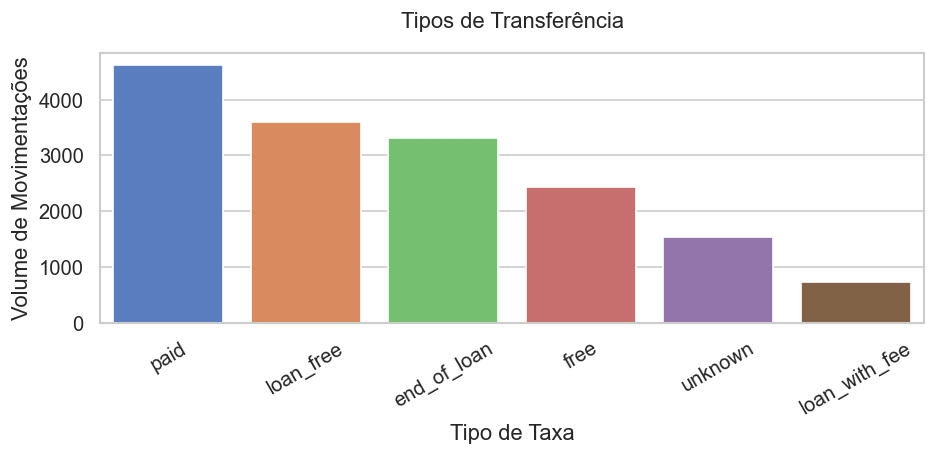

In [73]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df_transfers, 
    x='fee_type', 
    order=df_transfers['fee_type'].value_counts().index,
    palette='muted'
)

plt.title('Tipos de Transferência', pad=15)
plt.xlabel('Tipo de Taxa')
plt.ylabel('Volume de Movimentações')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 Comportamento de Precificação e Assimetria

Ao isolarmos apenas as negociações com fluxo de caixa, notamos uma **forte assimetria à direita** na distribuição dos valores pagos. A média é puxada para cima por transações extremas (*outliers*), distanciando-se fortemente da mediana. 

Adicionalmente, investigamos a correlação linear entre a avaliação estática do jogador (Valor de Mercado) e a precificação real executada pelos clubes (Fee).

In [ ]:
# Preparação das variáveis (conversão para Milhões)
vals_m = df_both['fee'] / 1e6
mv_m = df_both['market_value'] / 1e6

# Cálculo estatístico (Correlação)
corr_coef = df_both['market_value'].corr(df_both['fee'])
median_val = vals_m.median()
mean_val = vals_m.mean()

print(f"Dados preparados. Correlação R = {corr_coef:.2f}")

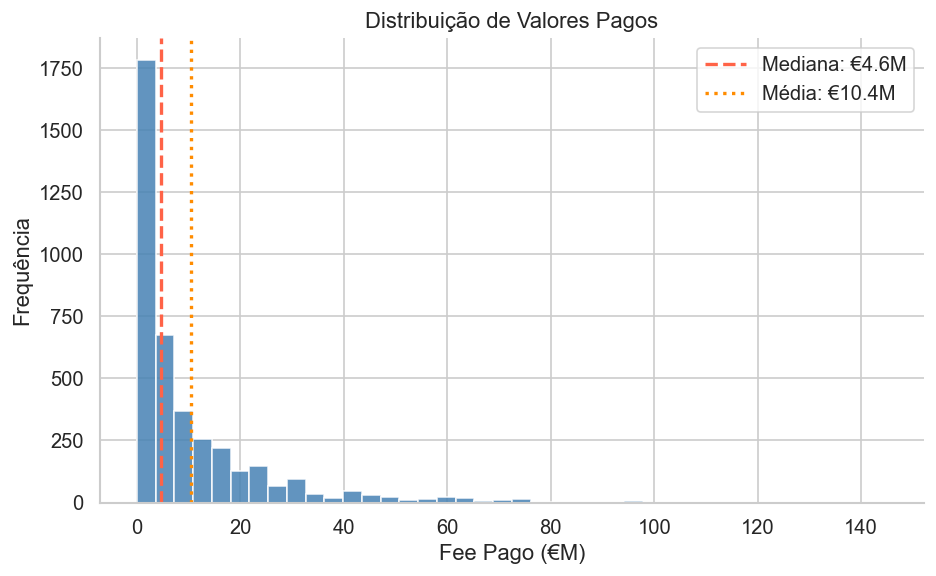

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plota o Histograma
ax.hist(vals_m, bins=40, color='steelblue', edgecolor='white', alpha=0.85)

# Adiciona as linhas de Média e Mediana
ax.axvline(vals_m.median(), color='tomato', lw=2, linestyle='--', label=f'Mediana: €{vals_m.median():.1f}M')
ax.axvline(vals_m.mean(), color='darkorange', lw=2, linestyle=':', label=f'Média: €{vals_m.mean():.1f}M')

# Configurações de texto e eixos
ax.set_xlabel('Fee Pago (€M)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Valores Pagos')
ax.legend()

# Limpeza de layout
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

In [77]:
fig2 = go.Figure()

# Adiciona a Dispersão (Scatter Plot)
fig2.add_trace(
    go.Scatter(
        x=mv_m, 
        y=vals_m, 
        mode='markers',
        marker=dict(color='steelblue', size=12, line=dict(width=1, color='white'), opacity=0.9),
        name='Transferência',
        hovertext=df_both.get('name', ''), 
        hovertemplate="<b>%{hovertext}</b><br>Valor de Mercado: €%{x:.1f}M<br>Fee Pago: €%{y:.1f}M<extra></extra>"
    )
)

# Adiciona a Linha de Identidade (Fee = MV)
lim_max = max(vals_m.max(), mv_m.max()) * 1.05
fig2.add_trace(
    go.Scatter(
        x=[0, lim_max], 
        y=[0, lim_max], 
        mode='lines',
        line=dict(color='red', dash='dash', width=3), 
        name='Pagamento = Valor de Mercado',
        hoverinfo='skip' 
    )
)

# Layout e Estilização
fig2.update_layout(
    title=dict(
        text=f'<b>Precificação do Mercado (Correlação r = {corr_coef:.2f})</b>',
        font=dict(size=24, color='black')
    ),
    
    # Eixo X
    xaxis=dict(
        title='<b>Valor de Mercado (€M)</b>',
        title_font=dict(size=20, color='black'),
        tickfont=dict(size=16, color='black'),
        showgrid=True,
        gridcolor='#cccccc',    # Cor da grade interna (cinza médio)
        gridwidth=1,
        showline=True,          
        linecolor='#cccccc',   
        linewidth=1,           
        mirror=True,            
        zeroline=True,
        zerolinecolor='#cccccc',
        zerolinewidth=1
    ),
    
    # Eixo Y
    yaxis=dict(
        title='<b>Fee Pago (€M)</b>',
        title_font=dict(size=20, color='black'),
        tickfont=dict(size=16, color='black'),
        showgrid=True,
        gridcolor='#cccccc',
        gridwidth=1,
        showline=True,
        linecolor='#cccccc',  
        linewidth=1,           
        mirror=True,            
        zeroline=True,
        zerolinecolor='#cccccc',
        zerolinewidth=1
    ),
    
    height=650, 
    width=1000,
    plot_bgcolor='white',       
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(t=80, b=80, l=80, r=60) 
)

fig2.show()

### 3.3 Resumo das Visualizações dos Dados 

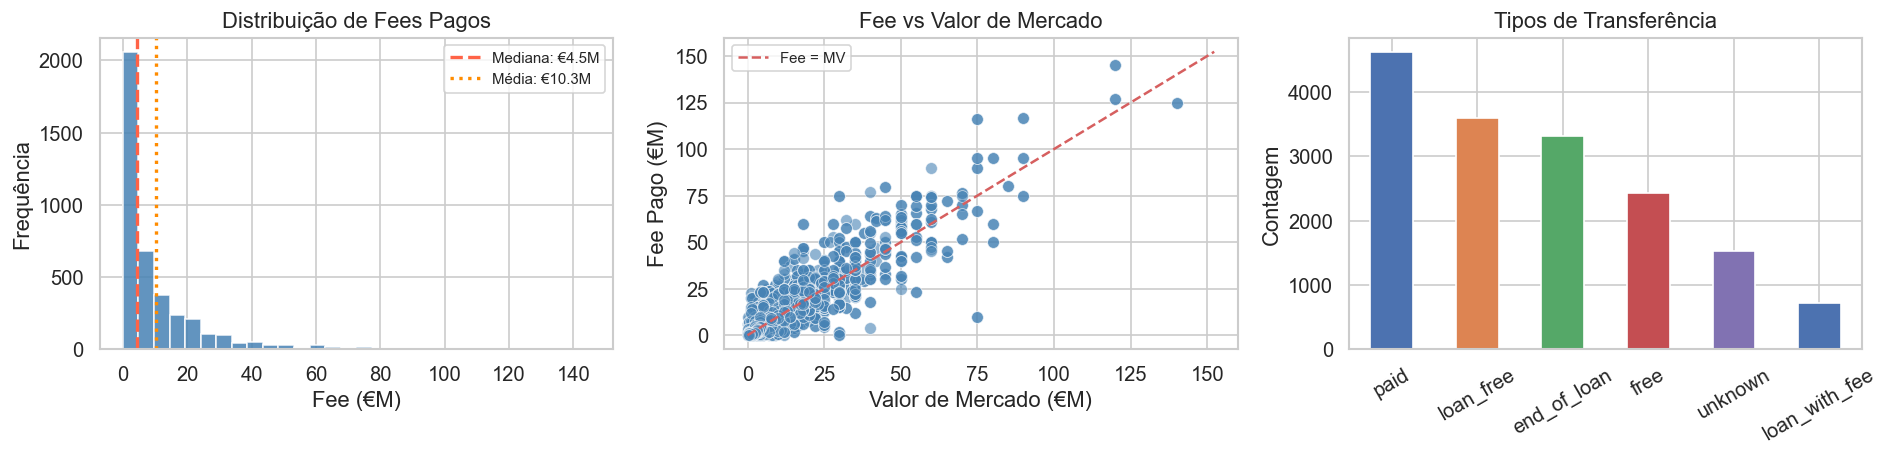

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição de fees pagos
ax = axes[0]
vals = df_paid['fee'].dropna() / 1e6
ax.hist(vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(vals.median(), color='tomato', lw=2, linestyle='--', label=f'Mediana: €{vals.median():.1f}M')
ax.axvline(vals.mean(), color='darkorange', lw=2, linestyle=':', label=f'Média: €{vals.mean():.1f}M')
ax.set_xlabel('Fee (€M)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Fees Pagos')
ax.legend(fontsize=9)

# Fee vs Valor de mercado
ax = axes[1]
df_both = df_paid.dropna(subset=['fee','market_value'])
ax.scatter(df_both['market_value']/1e6, df_both['fee']/1e6,
           alpha=0.6, s=50, color='steelblue', edgecolors='white', linewidths=0.5)
lim = max(df_both[['fee','market_value']].max()) / 1e6 * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Fee = MV')
ax.set_xlabel('Valor de Mercado (€M)')
ax.set_ylabel('Fee Pago (€M)')
ax.set_title('Fee vs Valor de Mercado')
ax.legend(fontsize=9)

# Composição de tipos de transferência
ax = axes[2]
type_counts = df_transfers['fee_type'].value_counts()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
type_counts.plot(kind='bar', ax=ax, color=colors[:len(type_counts)], edgecolor='white')
ax.set_title('Tipos de Transferência')
ax.set_xlabel('')
ax.set_ylabel('Contagem')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Prêmio bruto: fee vs. valor de mercado (π)

Definimos o **prêmio** como:
$$\pi = \frac{\text{fee} - \text{MV}}{\text{Market Value}} = \frac{\text{fee}}{\text{Market Value}} - 1$$

Um π > 0 indica que o clube comprador pagou **acima** do valor de mercado de referência.

In [177]:
df_pi = df_paid.dropna(subset=['fee','market_value']).copy()
df_pi['pi_pct'] = df_pi['premium_ratio'] * 100

print(f'Transferências com π calculável: {len(df_pi)}')
print(f'\nDistribuição de π (%):')
print(df_pi['pi_pct'].describe().round(1))
print(f'\nPropagação:')
print(f'  π > 0 (pagou acima do MV): {(df_pi["pi_pct"]>0).sum()} ({(df_pi["pi_pct"]>0).mean()*100:.0f}%)')
print(f'  π = 0 (pagou exato MV):    {(df_pi["pi_pct"]==0).sum()}')
print(f'  π < 0 (pagou abaixo MV):   {(df_pi["pi_pct"]<0).sum()} ({(df_pi["pi_pct"]<0).mean()*100:.0f}%)')

Transferências com π calculável: 4008

Distribuição de π (%):
count    4008.0
mean       33.0
std       196.6
min       -99.8
25%       -37.5
50%         0.0
75%        41.7
max      3900.0
Name: pi_pct, dtype: float64

Propagação:
  π > 0 (pagou acima do MV): 1793 (45%)
  π = 0 (pagou exato MV):    286
  π < 0 (pagou abaixo MV):   1929 (48%)


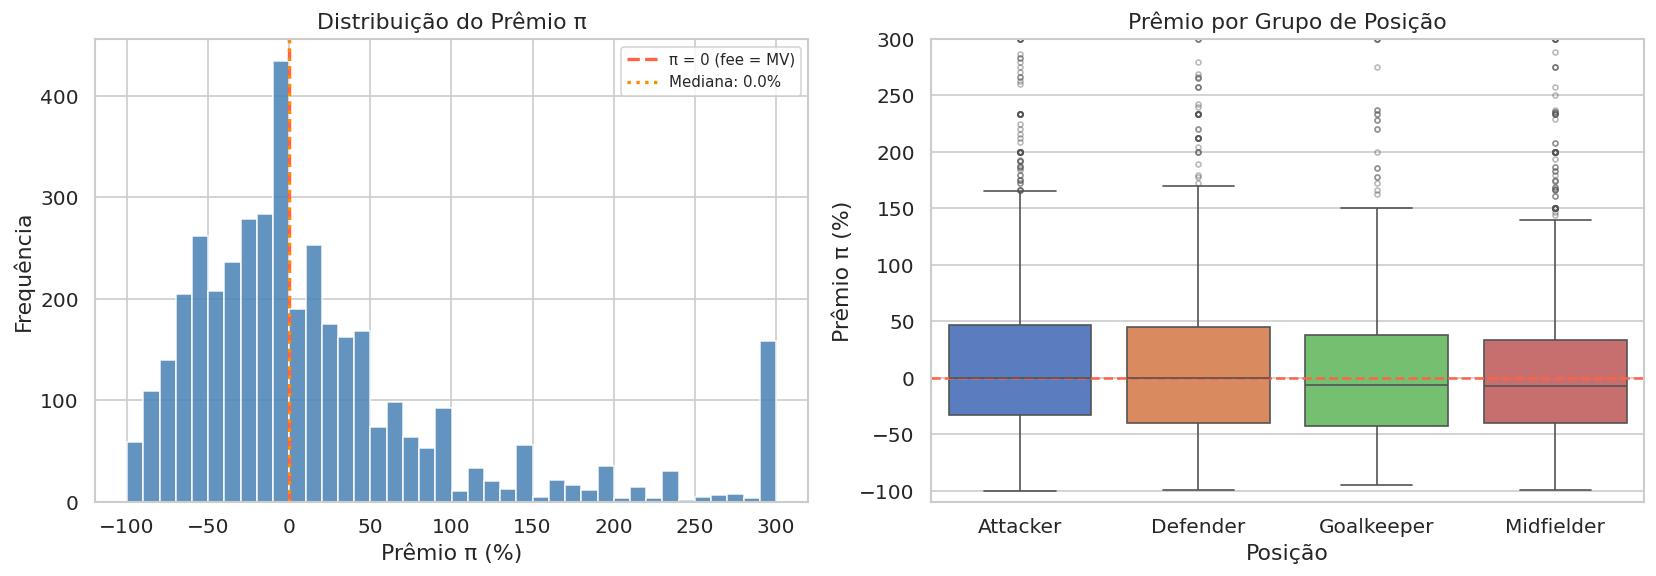

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de π
ax = axes[0]
clipped = df_pi['pi_pct'].clip(-100, 300)
ax.hist(clipped, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='tomato', lw=2, linestyle='--', label='π = 0 (fee = MV)')
ax.axvline(df_pi['pi_pct'].median(), color='darkorange', lw=2, linestyle=':',
           label=f'Mediana: {df_pi["pi_pct"].median():.1f}%')
ax.set_xlabel('Prêmio π (%)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do Prêmio π')
ax.legend(fontsize=9)

# π por grupo de posição
ax = axes[1]
order = df_pi.groupby('position_group')['pi_pct'].median().sort_values(ascending=False).index
sns.boxplot(data=df_pi, x='position_group', y='pi_pct', order=order,
            palette='muted', flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
ax.axhline(0, color='tomato', lw=1.5, linestyle='--')
ax.set_ylim(-110, 300)
ax.set_xlabel('Posição')
ax.set_ylabel('Prêmio π (%)')
ax.set_title('Prêmio por Grupo de Posição')

plt.tight_layout()
plt.show()

In [179]:
# π médio por clube comprador
buyer_pi = (df_pi.groupby(['buyer', 'source_league', 'season_id'])['pi_pct']
            .agg(['mean','median','count'])
            .rename(columns={'mean':'pi_mean','median':'pi_median','count':'n_compras'})
            .sort_values('pi_mean', ascending=False)
            .reset_index())
buyer_pi['club_label'] = buyer_pi['buyer'] + ' (' + buyer_pi['season_id'].astype(str) + ')'

print('Prêmio médio pago por clube/janela (entradas com fee real e MV):')
print(buyer_pi[['club_label', 'pi_mean', 'pi_median', 'n_compras']].to_string(index=False))

Prêmio médio pago por clube/janela (entradas com fee real e MV):
                     club_label       pi_mean   pi_median  n_compras
                 Chelsea (2024)  1.900000e+03 1900.000000          1
                Juventus (2024)  1.280000e+03 1280.000000          1
           R. Strasbourg (2024)  1.201429e+03  460.000000          4
                Atlético (2023)  9.432222e+02  -12.000000          3
                 NEOM SC (2025)  8.154167e+02   26.666667          4
              Al-Ettifaq (2024)  8.000000e+02  800.000000          1
               FC Vizela (2023)  7.200000e+02  720.000000          2
    RC Strasbourg Alsace (2024)  6.608185e+02  130.000000          8
           R. Strasbourg (2025)  6.500000e+02  650.000000          1
           Athletic Club (2024)  6.500000e+02  650.000000          1
           Cercle Brugge (2025)  6.332333e+02  -20.000000          5
             Galatasaray (2025)  5.500000e+02  550.000000          1
      Atlético de Madrid (2023)  5.278

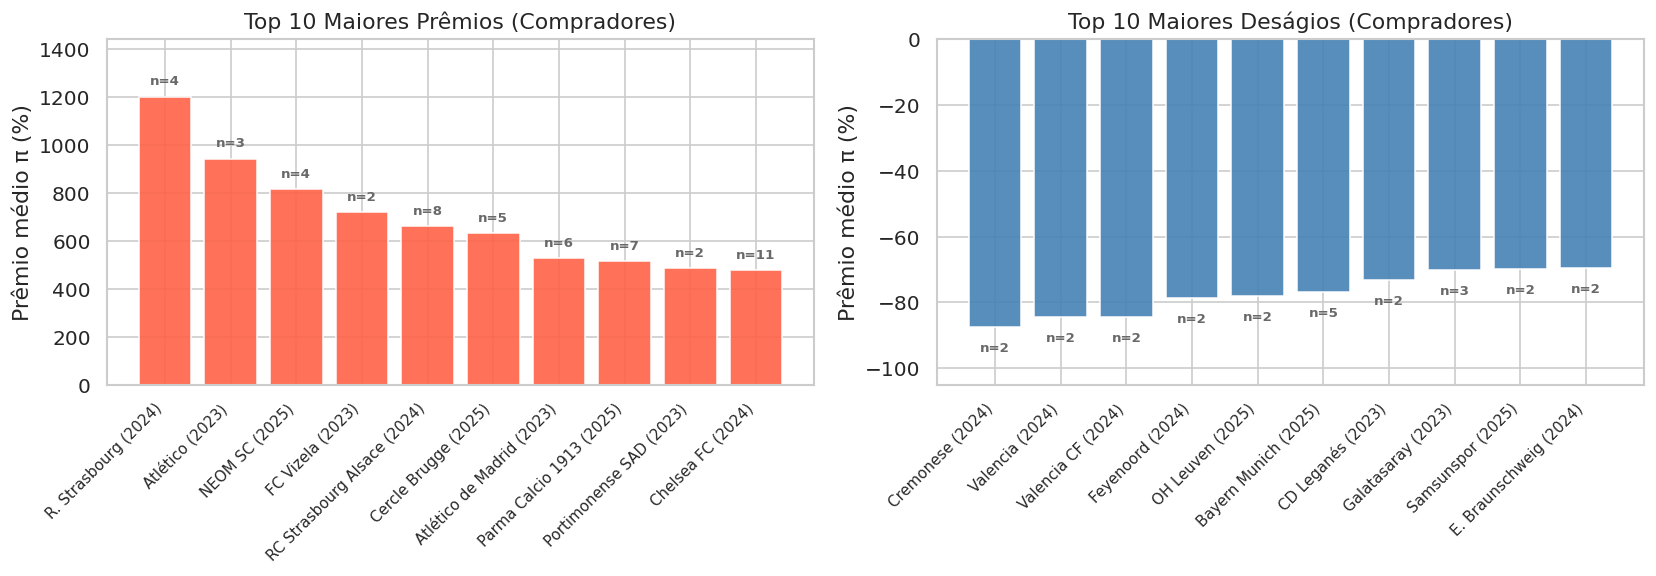

In [180]:
buyer_pi = buyer_pi[buyer_pi['n_compras'] >= 2]  # Filtrar para clubes com pelo menos 2 compras para evitar distorções por outliers em clubes com apenas 1 compra
top_pagadores = buyer_pi.sort_values(by='pi_mean', ascending=False).head(10)
top_barganhas = buyer_pi.sort_values(by='pi_mean', ascending=True).head(10)
top_extremos = pd.concat([top_pagadores, top_barganhas]).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Maiores Prêmios
cores1 = ['tomato'] * len(top_pagadores)
ax1.bar(range(len(top_pagadores)), top_pagadores['pi_mean'],
        color=cores1, edgecolor='white', alpha=0.9)
ax1.axhline(0, color='black', lw=1)
ax1.set_xticks(range(len(top_pagadores)))
ax1.set_xticklabels(top_pagadores['club_label'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Prêmio médio π (%)')
ax1.set_title('Top 10 Maiores Prêmios (Compradores)')
for i, (_, row) in enumerate(top_pagadores.iterrows()):
    ax1.text(i, row['pi_mean'] + top_pagadores['pi_mean'].max() * 0.03,
             f"n={row['n_compras']}", ha='center', va='bottom', fontsize=8,
             color='dimgray', fontweight='semibold')
ax1.set_ylim(0, top_pagadores['pi_mean'].max() * 1.2)

# Maiores Deságios
cores2 = ['steelblue'] * len(top_barganhas)
ax2.bar(range(len(top_barganhas)), top_barganhas['pi_mean'],
        color=cores2, edgecolor='white', alpha=0.9)
ax2.axhline(0, color='black', lw=1)
ax2.set_xticks(range(len(top_barganhas)))
ax2.set_xticklabels(top_barganhas['club_label'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Prêmio médio π (%)')
ax2.set_title('Top 10 Maiores Deságios (Compradores)')
for i, (_, row) in enumerate(top_barganhas.iterrows()):
    ax2.text(i, row['pi_mean'] + top_barganhas['pi_mean'].min() * 0.05,
             f"n={row['n_compras']}", ha='center', va='top', fontsize=8,
             color='dimgray', fontweight='semibold')
ax2.set_ylim(top_barganhas['pi_mean'].min() * 1.2, 0)

plt.tight_layout()
plt.show()

## 5. Análise do "prêmio do vendedor" — sinal bruto

**Pergunta central:** clubes que também realizaram saídas pagas na mesma janela de mercado tendem a pagar prêmios maiores nas suas contratações?

A hipótese do **prêmio do vendedor** é o núcleo deste trabalho: quando um clube recebe receita de uma venda, pode reutilizar esses recursos para contratar jogadores pagando acima do valor de mercado — por urgência de reposição, excesso de confiança pelo "dinheiro em caixa" ou pressão de torcida/diretoria.

Para testar esse sinal bruto, construímos dois grupos por janela liga-temporada:
- **Grupo Tratamento:** compras feitas por clubes que **também tiveram saídas pagas** na mesma janela
- **Grupo Controle:** compras feitas por clubes **sem saídas pagas** naquela janela

> **Nota sobre o grupo de controle:** Em grandes ligas, é muito raro um clube comprar sem ter vendido nada — o grupo de controle nesta análise conta com apenas 13 observações, o que limita o poder estatístico do teste binário. A análise contínua (receita de vendas vs. prêmio médio pago) no segundo gráfico é metodologicamente mais robusta e será o ponto de partida para a modelagem formal.

In [181]:
internal_clubs_list = list(df_clubs['club_name'].unique())

sellers_by_season = (
    df_transfers[(df_transfers['direction'] == 'Out') & (df_transfers['fee_type'] == 'paid')]
    .groupby(['source_league', 'season_id'])['club']
    .apply(set)
    .to_dict()
)

def checar_venda_na_janela(row, sellers_dict):
    chave = (row['source_league'], row['season_id'])
    if chave in sellers_dict:
        return row['club'] in sellers_dict[chave]
    return False

In [182]:
revenue_by_club = (
    df_transfers[(df_transfers['direction'] == 'Out') & (df_transfers['fee_type'] == 'paid')]
    .groupby(['club', 'source_league', 'season_id'])['fee']
    .sum()
    .rename('revenue_sales')
    .reset_index()
)


df_pi_in = df_transfers[df_transfers['direction'] == 'In'].copy()
df_pi_in['pi_pct'] = df_pi_in['premium_ratio'] * 100 
df_pi_in = df_pi_in.dropna(subset=['pi_pct'])
df_pi_in['sold_in_window'] = df_pi_in.apply(lambda r: checar_venda_na_janela(r, sellers_by_season), axis=1)
df_pi_in = df_pi_in.merge(
    revenue_by_club, 
    on=['club', 'source_league', 'season_id'], 
    how='left'
)
df_pi_in['revenue_sales'] = df_pi_in['revenue_sales'].fillna(0)

print(f'Entradas com π calculável (Janela Longitudinal): {len(df_pi_in)}')
print(f"- De clubes que venderam na mesma janela: {df_pi_in['sold_in_window'].sum()}")
print(f"- De clubes que não venderam na mesma janela: {(~df_pi_in['sold_in_window']).sum()}")

Entradas com π calculável (Janela Longitudinal): 2488
- De clubes que venderam na mesma janela: 2475
- De clubes que não venderam na mesma janela: 13


In [183]:
grupo_vendeu = df_pi_in[df_pi_in['sold_in_window']]['pi_pct']
grupo_nao_vendeu = df_pi_in[~df_pi_in['sold_in_window']]['pi_pct']

print('π (%) para clubes QUE VENDERAM NA JANELA:')
print(grupo_vendeu.describe().round(1))
print('\nπ (%) para clubes QUE NÃO VENDERAM NA JANELA:')
print(grupo_nao_vendeu.describe().round(1))

diff_mediana = grupo_vendeu.median() - grupo_nao_vendeu.median()
diff_media = grupo_vendeu.mean() - grupo_nao_vendeu.mean()
print(f'Diferença de medianas: {diff_mediana:+.1f} p.p.')
print(f'Diferença de médias: {diff_media:+.1f} p.p.\n')

π (%) para clubes QUE VENDERAM NA JANELA:
count    2475.0
mean       30.0
std       203.7
min       -99.0
25%       -50.0
50%        -6.0
75%        41.1
max      3900.0
Name: pi_pct, dtype: float64

π (%) para clubes QUE NÃO VENDERAM NA JANELA:
count     13.0
mean     -10.1
std       65.3
min      -85.0
25%      -66.7
50%      -20.0
75%        0.0
max      122.2
Name: pi_pct, dtype: float64
Diferença de medianas: +14.0 p.p.
Diferença de médias: +40.1 p.p.



In [184]:
# Teste t de Welch (não assume variâncias iguais)
t_stat, p_val = stats.ttest_ind(grupo_vendeu, grupo_nao_vendeu, equal_var=False)
# Teste de Mann-Whitney U (Unicaudal: hipótese de que quem vendeu paga um prêmio MAIOR)
u_stat, p_mann = stats.mannwhitneyu(grupo_vendeu, grupo_nao_vendeu, alternative='greater')

print(f'Teste t de Welch: t={t_stat:.3f}, p={p_val:.4f}')
print(f'Mann-Whitney U (vendeu > não vendeu): U={u_stat:.0f}, p={p_mann:.4f}\n')
if p_mann < 0.05:
    print('Sinal positivo! Clubes que realizaram saídas tendem a pagar um π significativamente MAIOR (p<0.05).')
elif p_mann < 0.1:
    print('Sinal fraco (0.05 < p < 0.10). Existe uma tendência de comportamento, mas sem significância forte.')
else:
    print('Sem sinal claro nos dados brutos. Confundidores econômicos provavelmente dominam essa relação.')

print('\nNota: Esta é uma análise estatística bruta agregada unificando múltiplos anos/ligas.')
print('Ela aponta a tendência macro do ecossistema, mas necessita do controle dos efeitos fixos (C1-C6 da proposta).')

Teste t de Welch: t=2.160, p=0.0496
Mann-Whitney U (vendeu > não vendeu): U=18050, p=0.2238

Sem sinal claro nos dados brutos. Confundidores econômicos provavelmente dominam essa relação.

Nota: Esta é uma análise estatística bruta agregada unificando múltiplos anos/ligas.
Ela aponta a tendência macro do ecossistema, mas necessita do controle dos efeitos fixos (C1-C6 da proposta).


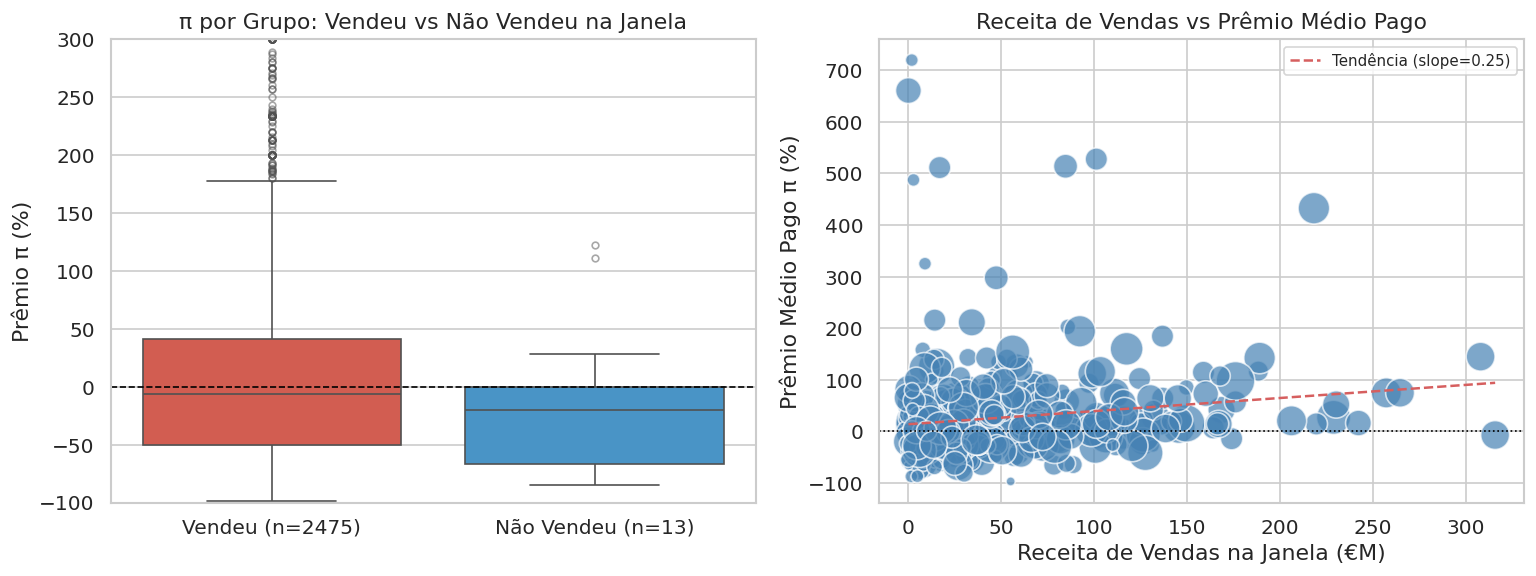

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
df_plot = df_pi_in.copy()
df_plot['Grupo'] = df_plot['sold_in_window'].map({
    True: 'Vendeu (n={})'.format(len(grupo_vendeu)),
    False: 'Não Vendeu (n={})'.format(len(grupo_nao_vendeu))
})

sns.boxplot(data=df_plot, x='Grupo', y='pi_pct',
            palette=['#e74c3c','#3498db'], flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_ylim(-100, 300) 
ax.set_ylabel('Prêmio π (%)')
ax.set_title('π por Grupo: Vendeu vs Não Vendeu na Janela')
ax.set_xlabel('')

ax = axes[1]
scatter_data = (df_pi_in.groupby(['buyer', 'source_league', 'season_id'])
                .agg(
                    pi_mean=('pi_pct', 'mean'), 
                    revenue=('revenue_sales', 'first'), 
                    n=('pi_pct', 'count')
                )
                .reset_index())

ax.scatter(scatter_data['revenue']/1e6, scatter_data['pi_mean'],
           s=scatter_data['n']*30, alpha=0.7, color='steelblue', edgecolors='white')

m, b = np.polyfit(scatter_data['revenue']/1e6, scatter_data['pi_mean'], 1)
x_line = np.linspace(0, scatter_data['revenue'].max()/1e6, 100)
ax.plot(x_line, m*x_line + b, 'r--', lw=1.5, label=f'Tendência (slope={m:.2f})')
ax.axhline(0, color='black', lw=1, linestyle=':')
ax.set_xlabel('Receita de Vendas na Janela (€M)')
ax.set_ylabel('Prêmio Médio Pago π (%)')
ax.set_title('Receita de Vendas vs Prêmio Médio Pago')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Análise de rede: grafo de transferências

O mercado de transferências pode ser modelado como uma **rede direcionada e ponderada**: cada clube é um nó e cada transferência paga é uma aresta com direção do vendedor para o comprador, ponderada pelo valor financeiro da transação (em €).

Um grafo separado é construído para cada temporada (2023, 2024 e 2025) usando **NetworkX**. Para cada clube do ecossistema são calculadas métricas de centralidade estrutural:
- **`in_degree`**: número de vendedores distintos que forneceram jogadores ao clube
- **`out_degree`**: número de compradores distintos que adquiriram jogadores do clube
- **`in_strength`**: volume financeiro total gasto em compras (€) — proxy de *poder de investimento*
- **`out_strength`**: volume financeiro total arrecadado em vendas (€) — proxy de *capacidade de geração de receita*
- **`net_flow`**: saldo financeiro líquido na rede (`in_strength − out_strength`)

Essas métricas serão utilizadas como **variáveis de controle estrutural** no modelo econométrico, capturando a posição do clube na hierarquia do mercado independentemente de suas características observáveis.

In [186]:
# Criamos uma lista para armazenar os DataFrames de métricas de cada temporada
dfs_metricas_temporais = []

# Mapeamos todos os clubes originais das ligas 
internal_clubs = set(df_clubs['club_name'].unique())

# Um grafo isolado para cada temporada
for season in sorted(df_transfers['season_id'].unique()):
    
    # 1. Isolar os dados de transferências pagas daquela temporada específica
    df_season = df_transfers[
        (df_transfers['fee_type'] == 'paid') & 
        (df_transfers['season_id'] == season)
    ].copy()
    
    # Inicializa o Grafo Dirigido da temporada correspondente
    G_season = nx.DiGraph()
    
    # Adicionar os nós base
    for club in internal_clubs:
        G_season.add_node(club, internal_ecosystem=True)
        
    # 2. Adicionar as arestas (fluxos financeiros) daquela temporada específica
    for _, row in df_season.iterrows():
        buyer  = row['buyer']
        seller = row['seller']
        fee    = row['fee'] if pd.notna(row['fee']) else 0
        
        if pd.notna(buyer) and pd.notna(seller) and buyer != seller:
            # Garante que clubes de fora mapeados naquela janela entrem com a flag False
            if not G_season.has_node(buyer):
                G_season.add_node(buyer, internal_ecosystem=False)
            if not G_season.has_node(seller):
                G_season.add_node(seller, internal_ecosystem=False)
                
            # Acumula os valores dentro da mesma temporada
            if G_season.has_edge(seller, buyer):
                G_season[seller][buyer]['weight'] += fee
                G_season[seller][buyer]['n_transfers'] += 1
            else:
                G_season.add_edge(seller, buyer, weight=fee, n_transfers=1)
                
    # Diagnóstico rápido da janela no terminal 
    print(f"[Temporada {season}] Grafo gerado: {G_season.number_of_nodes()} nós | {G_season.number_of_edges()} arestas")
                
    centrality_season = {}
    for club in internal_clubs:
        if club in G_season:
            # Força de entrada (investimento) e saída (arrecadação) ponderadas pelo valor (€)
            in_strength = G_season.in_degree(club, weight='weight')
            out_strength = G_season.out_degree(club, weight='weight')
            
            centrality_season[club] = {
                'in_degree': G_season.in_degree(club),
                'out_degree': G_season.out_degree(club),
                'in_strength': in_strength,
                'out_strength': out_strength,
                'net_flow': in_strength - out_strength  # Balanço financeiro líquido na rede
            }
            
    # Converte os resultados da temporada em DataFrame e injeta a chave temporal
    df_season_net = pd.DataFrame(centrality_season).T.reset_index().rename(columns={'index': 'club'})
    df_season_net['season_id'] = season  
    dfs_metricas_temporais.append(df_season_net)

# Junta os resultados de todas as janelas em uma única tabela 
df_net_longitudinal = pd.concat(dfs_metricas_temporais, ignore_index=True)
# Ordena cronologicamente e coloca os clubes que mais gastaram no topo
df_net_longitudinal = df_net_longitudinal.sort_values(['season_id', 'in_strength'], ascending=[True, False])

print('DataFrame Longitudinal de Redes Concluído com Sucesso!')
print('Dimensões finais (linhas x colunas):', df_net_longitudinal.shape)

[Temporada 2023] Grafo gerado: 790 nós | 1418 arestas
[Temporada 2024] Grafo gerado: 807 nós | 1404 arestas
[Temporada 2025] Grafo gerado: 834 nós | 1584 arestas
DataFrame Longitudinal de Redes Concluído com Sucesso!
Dimensões finais (linhas x colunas): (822, 7)


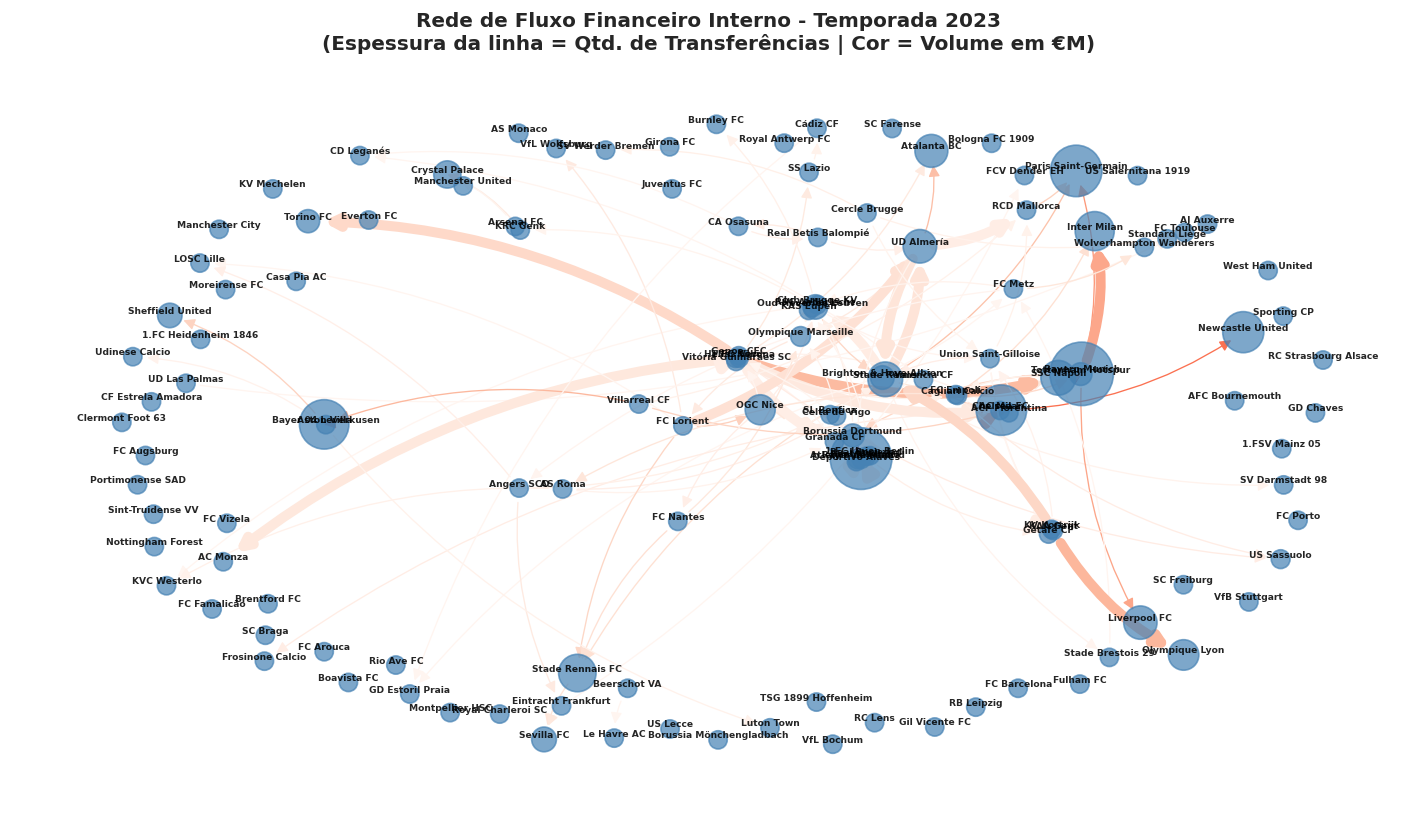

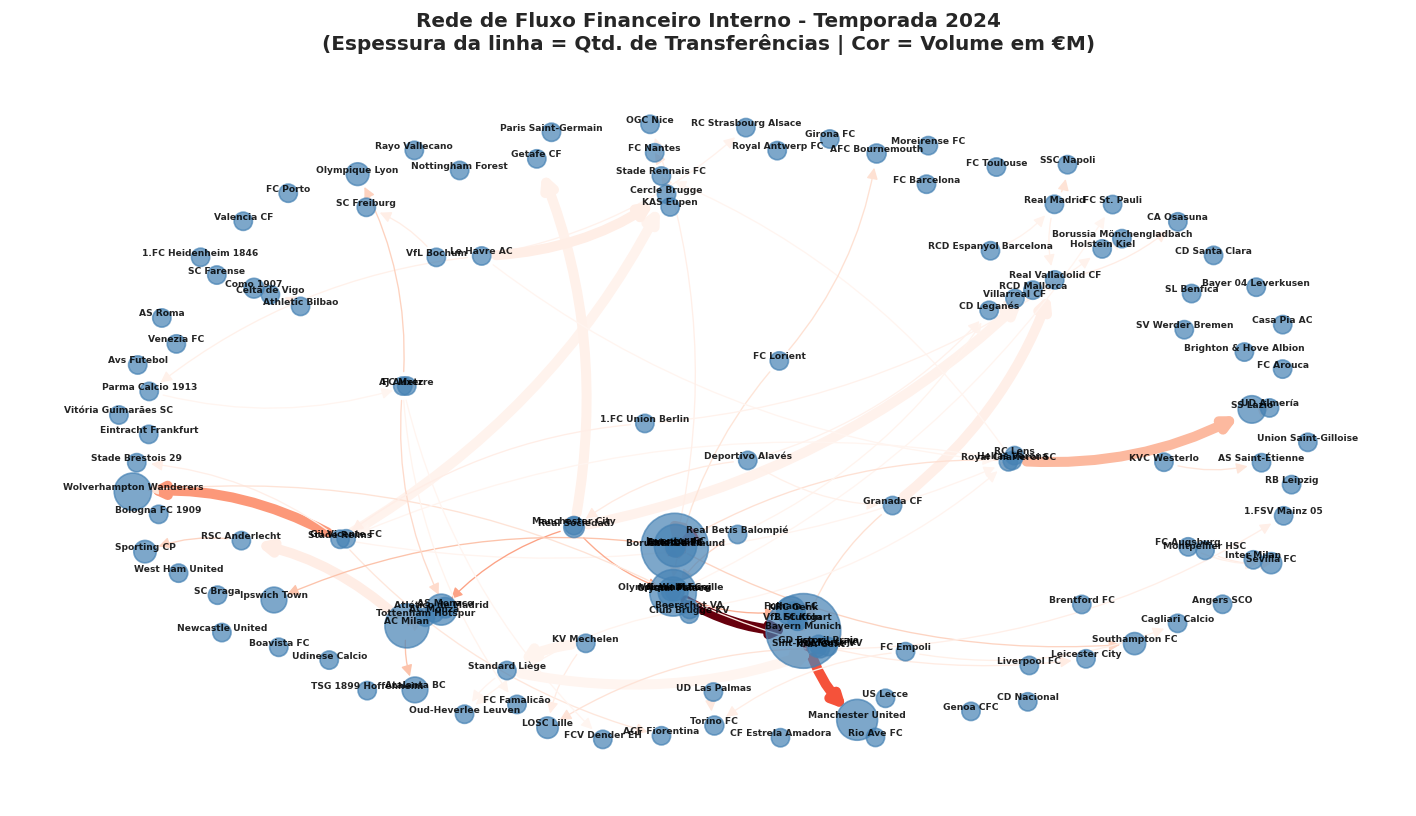

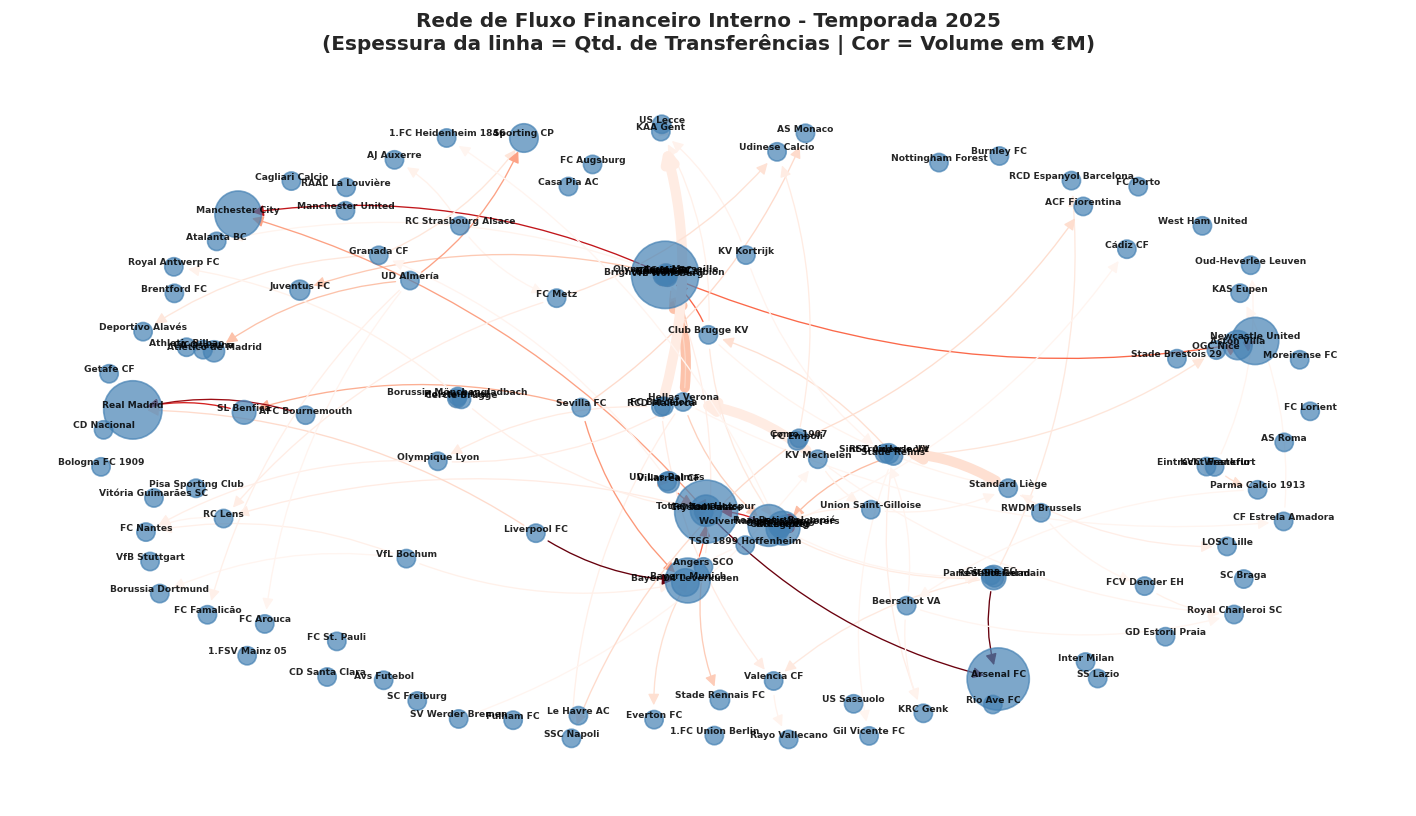

In [187]:
internal_clubs_list = list(df_clubs['club_name'].unique())
for season in sorted(df_transfers['season_id'].unique()):
    df_season = df_transfers[
        (df_transfers['fee_type'] == 'paid') & 
        (df_transfers['season_id'] == season)
    ].copy()
    G_temp = nx.DiGraph()
    for _, row in df_season.iterrows():
        buyer, seller, fee = row['buyer'], row['seller'], row['fee']
        if pd.notna(buyer) and pd.notna(seller) and buyer != seller:
            if G_temp.has_edge(seller, buyer):
                G_temp[seller][buyer]['weight'] += fee if pd.notna(fee) else 0
                G_temp[seller][buyer]['n_transfers'] += 1  # Incrementa contagem de transações
            else:
                G_temp.add_edge(seller, buyer, weight=fee if pd.notna(fee) else 0, n_transfers=1)
 
    nodes_presente = [c for c in internal_clubs_list if c in G_temp]
    H = G_temp.subgraph(nodes_presente).copy()

    fig, ax = plt.subplots(figsize=(12, 7))
    if H.number_of_edges() > 0:
        pos = nx.spring_layout(H, seed=42, k=2.5)
        in_strengths = dict(H.in_degree(weight='weight'))
        node_sizes = [max(120, in_strengths.get(n, 0) / 1e5) for n in H.nodes]
        nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color='steelblue', alpha=0.7, ax=ax)

        labels_todos = {n: n for n in H.nodes}

        nx.draw_networkx_labels(H, pos, labels=labels_todos, 
                                font_size=5.5, font_weight='bold', 
                                font_color='black', alpha=0.85,
                                verticalalignment='bottom', ax=ax)
        
        edges = H.edges(data=True)
    
        num_transfers = [d['n_transfers'] for _, _, d in edges]
        max_transfers = max(num_transfers) if num_transfers else 1
        edge_widths = [0.8 + (5.2 * (nt - 1) / max(1, max_transfers - 1)) if max_transfers > 1 else 1.5 for nt in num_transfers]
        
        weights = [d['weight'] / 1e6 for _, _, d in edges]
        
        nx.draw_networkx_edges(H, pos,
                               width=edge_widths,
                               edge_color=weights, edge_cmap=plt.cm.Reds,
                               arrows=True, arrowsize=14,
                               connectionstyle='arc3,rad=0.15', ax=ax)
            
        ax.set_title(f'Rede de Fluxo Financeiro Interno - Temporada {season}\n'
                     f'(Espessura da linha = Qtd. de Transferências | Cor = Volume em €M)', 
                     fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Sem movimentações diretas internas registradas na temporada {season}.',
                ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(f'Rede de Fluxo Interno - Temporada {season}', fontsize=12, fontweight='bold')
        
    ax.axis('off')
    plt.tight_layout()
    plt.show()

Linha Grossa e Vermelha Escura: Os clubes negociaram muitos jogadores e gastaram muito dinheiro - parceria comercial forte.

Linha Grossa e Vermelha Clara: Os clubes negociaram vários jogadores, mas por valores muito baixos - provavelmente trocas de jogadores da base ou atletas em fim de contrato.

Linha Fina e Vermelha Escura: Houve apenas uma única transferência entre os clubes, mas ela foi uma contratação de alto valor - um caso isolado que injetou muito dinheiro de uma vez só no vendedor

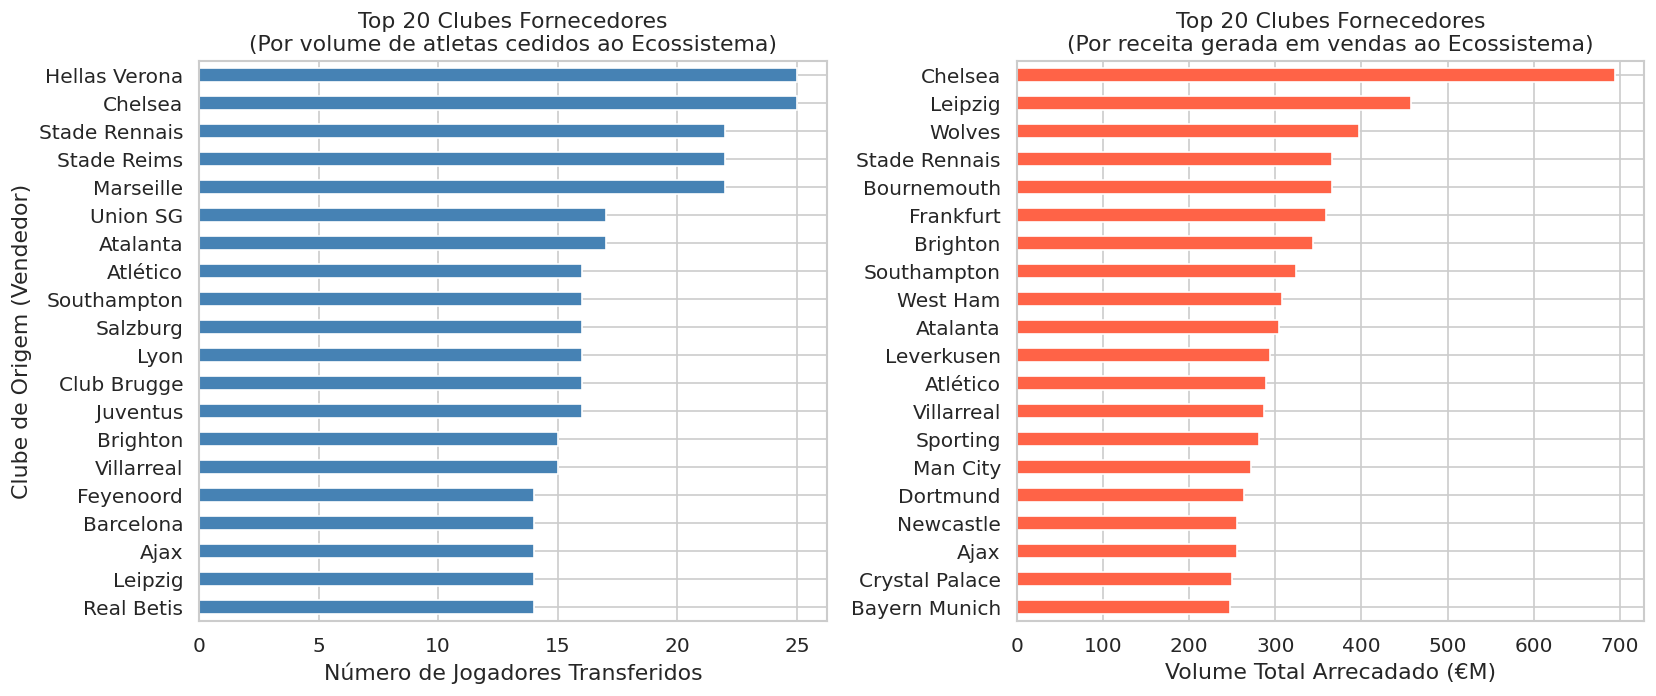

In [188]:
df_paid_in = df_transfers[
    (df_transfers['fee_type'] == 'paid') & 
    (df_transfers['buyer'].isin(internal_clubs_list))
].copy()

origin_counts_players = (df_paid_in.groupby('seller')
                         .agg(
                             n_players=('player', 'count'),
                             total_fee=('fee', 'sum')
                         )
                         .sort_values('n_players', ascending=False)
                         .head(20))

origin_counts_fee = (df_paid_in.groupby('seller')
                     .agg(
                         n_players=('player', 'count'),
                         total_fee=('fee', 'sum')
                     )
                     .sort_values('total_fee', ascending=False)
                     .head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
origin_counts_players['n_players'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de Jogadores Transferidos')
ax.set_ylabel('Clube de Origem (Vendedor)')
ax.set_title('Top 20 Clubes Fornecedores\n(Por volume de atletas cedidos ao Ecossistema)')
ax.invert_yaxis()

ax = axes[1]
(origin_counts_fee['total_fee']/1e6).plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
ax.set_xlabel('Volume Total Arrecadado (€M)')
ax.set_ylabel('')
ax.set_title('Top 20 Clubes Fornecedores\n(Por receita gerada em vendas ao Ecossistema)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Perfil dos jogadores transferidos

Para entender **quem** está sendo negociado no ecossistema, analisamos o perfil demográfico e esportivo dos atletas envolvidos nas transferências pagas. São exploradas quatro dimensões:

1. **Distribuição etária** — concentração de idades nas negociações pagas (onde se concentra o pico de valor e liquidez)
2. **Volume financeiro por posição** — qual grupo tático movimenta mais dinheiro
3. **Fee vs. Idade** — como o preço pago evolui com a fase da carreira do atleta (tamanho dos pontos = valor de mercado)
4. **Prêmio π mediano por faixa etária** — se determinadas faixas etárias geram sobrepreços sistematicamente maiores

Ao final, o gráfico de **top 15 nacionalidades** mapeia quais países exportam mais jogadores para as ligas do ecossistema analisado.

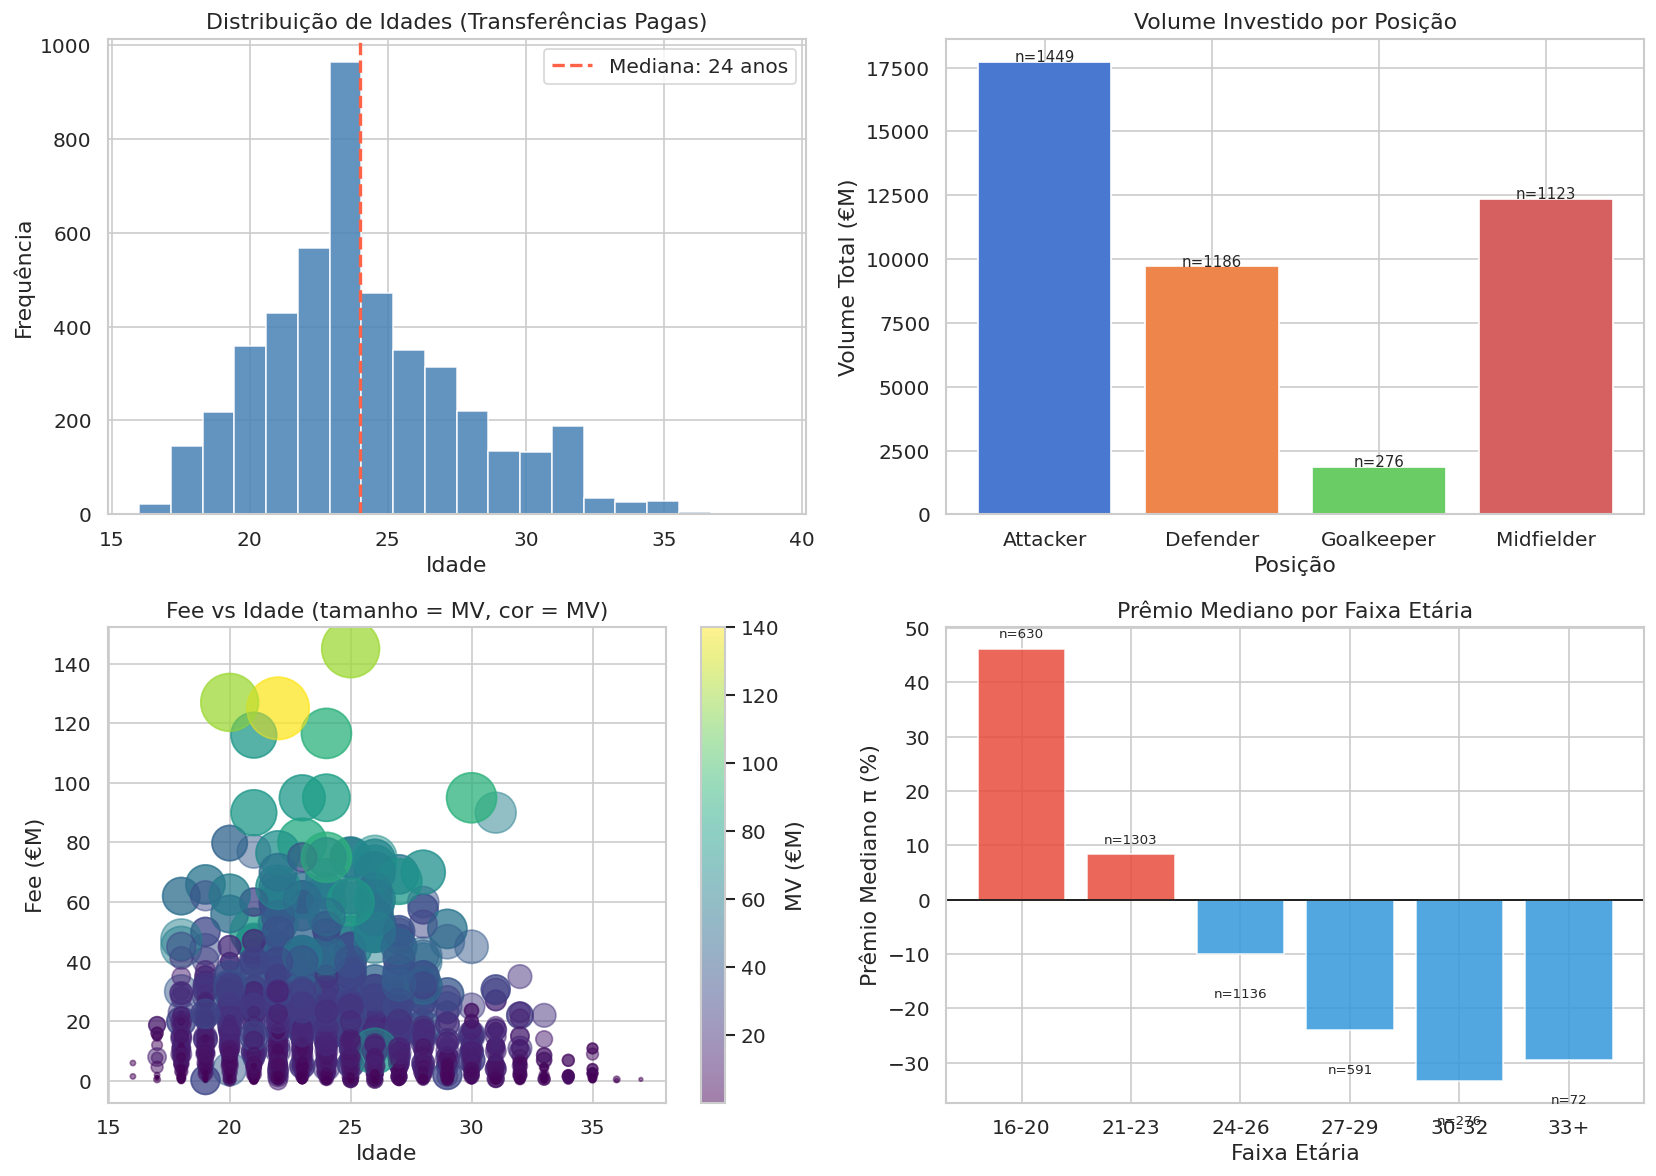

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição de idades nas transferências pagas
ax = axes[0,0]
df_paid['age'].dropna().hist(bins=20, ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_paid['age'].median(), color='tomato', lw=2, linestyle='--',
           label=f'Mediana: {df_paid["age"].median():.0f} anos')
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Idades (Transferências Pagas)')
ax.legend()

# 2. Volume por posição
ax = axes[0,1]
pos_vol = (df_paid.groupby('position_group')
           .agg(total_fee=('fee','sum'), n=('fee','count'))
           .reset_index()
           .sort_values("total_fee", ascending=False))
colors = sns.color_palette('muted', len(pos_vol))
bars = ax.bar(pos_vol['position_group'], pos_vol['total_fee']/1e6, color=colors, edgecolor='white')
for bar, n in zip(bars, pos_vol['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'n={n}', ha='center', fontsize=9)
ax.set_xlabel('Posição')
ax.set_ylabel('Volume Total (€M)')
ax.set_title('Volume Investido por Posição')

# 3. Fee médio vs idade (scatter com tamanho = market_value)
ax = axes[1,0]
df_both = df_paid.dropna(subset=['fee','market_value','age'])
sc = ax.scatter(df_both['age'], df_both['fee']/1e6,
                s=df_both['market_value']/1e5, alpha=0.5,
                c=df_both['market_value']/1e6, cmap='viridis')
plt.colorbar(sc, ax=ax, label='MV (€M)')
ax.set_xlabel('Idade')
ax.set_ylabel('Fee (€M)')
ax.set_title('Fee vs Idade (tamanho = MV, cor = MV)')

# 4. Prêmio π por faixa etária
ax = axes[1,1]
df_pi_age = df_pi.copy()
df_pi_age['age_bin'] = pd.cut(df_pi_age['age'], bins=[15,20,23,26,29,32,40],
                               labels=['16-20','21-23','24-26','27-29','30-32','33+'])
age_pi = df_pi_age.groupby('age_bin', observed=True)['pi_pct'].agg(['median','mean','count']).reset_index()
ax.bar(age_pi['age_bin'].astype(str), age_pi['median'],
       color=['#e74c3c' if v > 0 else '#3498db' for v in age_pi['median']],
       edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1)
for i, row in age_pi.iterrows():
    ax.text(i, row['median'] + (2 if row['median'] >= 0 else -8),
            f"n={row['count']:.0f}", ha='center', fontsize=8)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Prêmio Mediano π (%)')
ax.set_title('Prêmio Mediano por Faixa Etária')

plt.tight_layout()
plt.show()

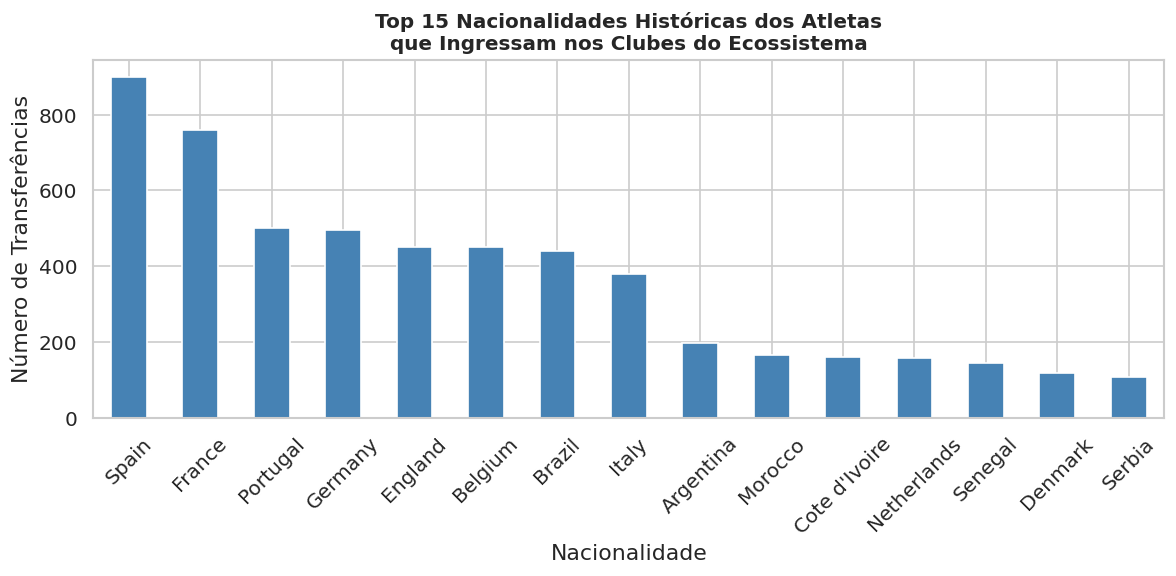

In [71]:
internal_clubs_list = list(df_clubs['club_name'].unique())
df_internal_inputs = df_transfers[df_transfers['buyer'].isin(internal_clubs_list)].copy()
nat_counts = df_internal_inputs['nationality'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
nat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Nacionalidade')
ax.set_ylabel('Número de Transferências')
ax.set_title('Top 15 Nacionalidades Históricas dos Atletas\nque Ingressam nos Clubes do Ecossistema', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Saldo líquido dos clubes e perfil comprador/vendedor

Esta seção classifica os clubes segundo seu comportamento histórico agregado no mercado. Para cada clube, são somadas todas as **saídas pagas** (receita de vendas) e todas as **entradas pagas** (despesa em compras) ao longo das três temporadas, gerando o **saldo líquido acumulado**.

- **Saldo positivo → Formadores/Exportadores líquidos:** geram mais receita de vendas do que gastam em contratações. Geralmente são clubes de ligas menores ou com forte academia de base.
- **Saldo negativo → Compradores puros:** investem sistematicamente mais do que arrecadam. Tipicamente grandes clubes financiados por capital externo.

Essa classificação é uma **variável de controle fundamental** para o modelo econométrico: o perfil estrutural comprador/vendedor de um clube está correlacionado tanto com sua receita de vendas quanto com o prêmio médio que ele tende a pagar — e precisa ser controlado para isolar o efeito causal do *prêmio do vendedor*.

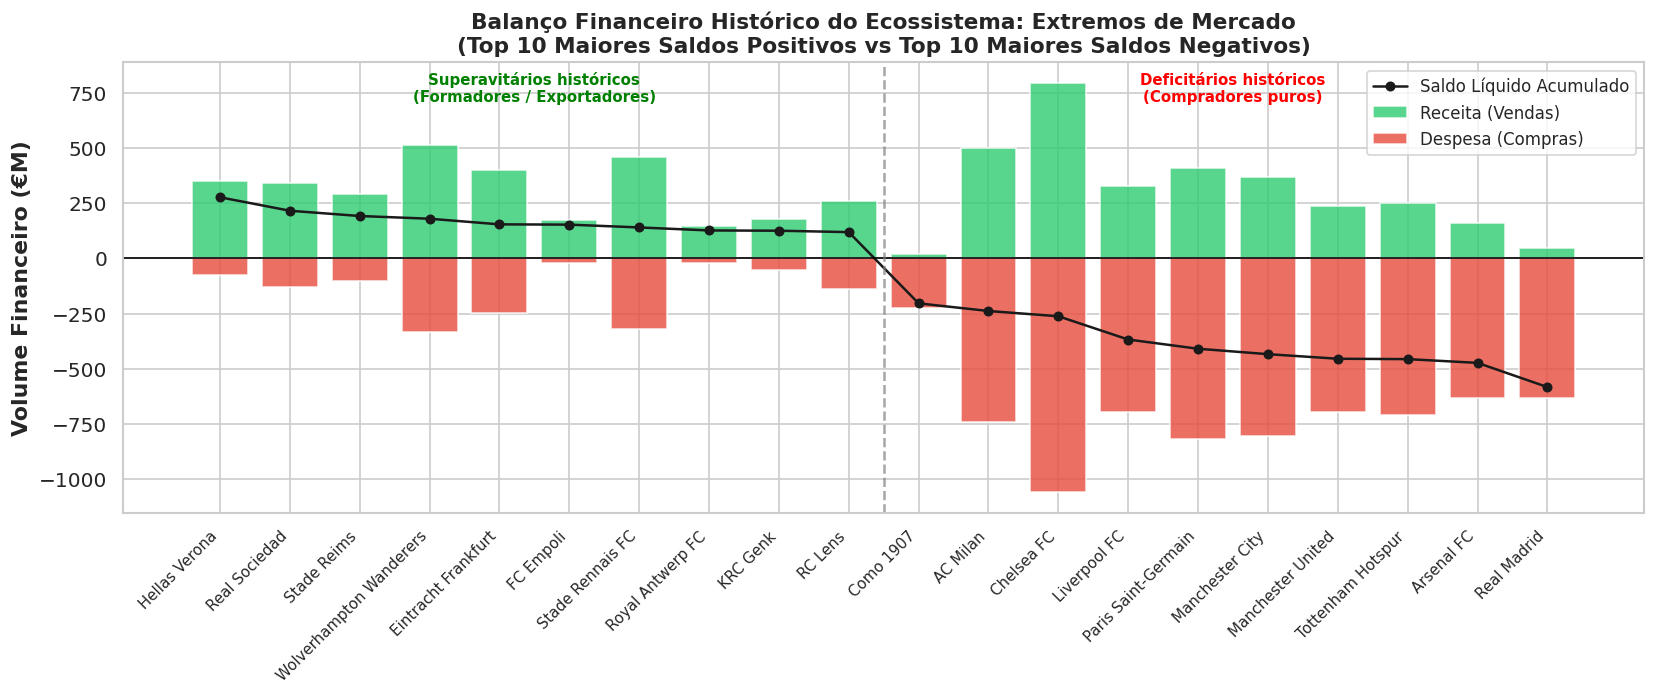


Detalhes dos Saldos Líquidos Acumulados (€M):
Hellas Verona              278.06
Real Sociedad              216.90
Stade Reims                193.00
Wolverhampton Wanderers    180.60
Eintracht Frankfurt        155.04
FC Empoli                  153.79
Stade Rennais FC           141.03
Royal Antwerp FC           127.35
KRC Genk                   126.15
RC Lens                    119.78
Como 1907                 -203.82
AC Milan                  -238.56
Chelsea FC                -262.40
Liverpool FC              -368.15
Paris Saint-Germain       -409.97
Manchester City           -434.62
Manchester United         -455.43
Tottenham Hotspur         -457.15
Arsenal FC                -474.17
Real Madrid               -584.00


In [74]:
internal_clubs_list = list(df_clubs['club_name'].unique())
spend_buy = (df_transfers[(df_transfers['fee_type'] == 'paid') & (df_transfers['buyer'].isin(internal_clubs_list))]
             .groupby('buyer')['fee'].sum().rename('spend'))

rev_sell = (df_transfers[(df_transfers['fee_type'] == 'paid') & (df_transfers['seller'].isin(internal_clubs_list))]
            .groupby('seller')['fee'].sum().rename('revenue'))

df_balance = pd.DataFrame({'spend': spend_buy, 'revenue': rev_sell}).fillna(0)
df_balance['net'] = df_balance['revenue'] - df_balance['spend']
df_lucro = df_balance.sort_values('net', ascending=False).head(10)
df_gasto = df_balance.sort_values('net', ascending=True).head(10).iloc[::-1] # Inverte para o pior ficar na ponta
df_plot_extremos = pd.concat([df_lucro, df_gasto])

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(df_plot_extremos))
ax.bar(x, df_plot_extremos['revenue']/1e6, label='Receita (Vendas)', color='#2ecc71', alpha=0.8, edgecolor='white')
ax.bar(x, -df_plot_extremos['spend']/1e6, label='Despesa (Compras)', color='#e74c3c', alpha=0.8, edgecolor='white')
ax.plot(x, df_plot_extremos['net']/1e6, 'ko-', lw=1.5, ms=5, label='Saldo Líquido Acumulado')
ax.axhline(0, color='black', lw=1)
ax.axvline(9.5, color='gray', linestyle='--', alpha=0.7) 
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot_extremos.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Volume Financeiro (€M)', fontweight='bold')
ax.set_title('Balanço Financeiro Histórico do Ecossistema: Extremos de Mercado\n'
             '(Top 10 Maiores Saldos Positivos vs Top 10 Maiores Saldos Negativos)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.text(4.5, ax.get_ylim()[1]*0.8, "Superavitários históricos\n(Formadores / Exportadores)", ha='center', color='green', fontsize=9, fontweight='bold')
ax.text(14.5, ax.get_ylim()[1]*0.8, "Deficitários históricos\n(Compradores puros)", ha='center', color='red', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDetalhes dos Saldos Líquidos Acumulados (€M):')
print((df_plot_extremos['net']/1e6).round(2).to_string())

## 9. Correlação entre variáveis para modelo hedônico

Exploramos quais variáveis mais se correlacionam com o fee

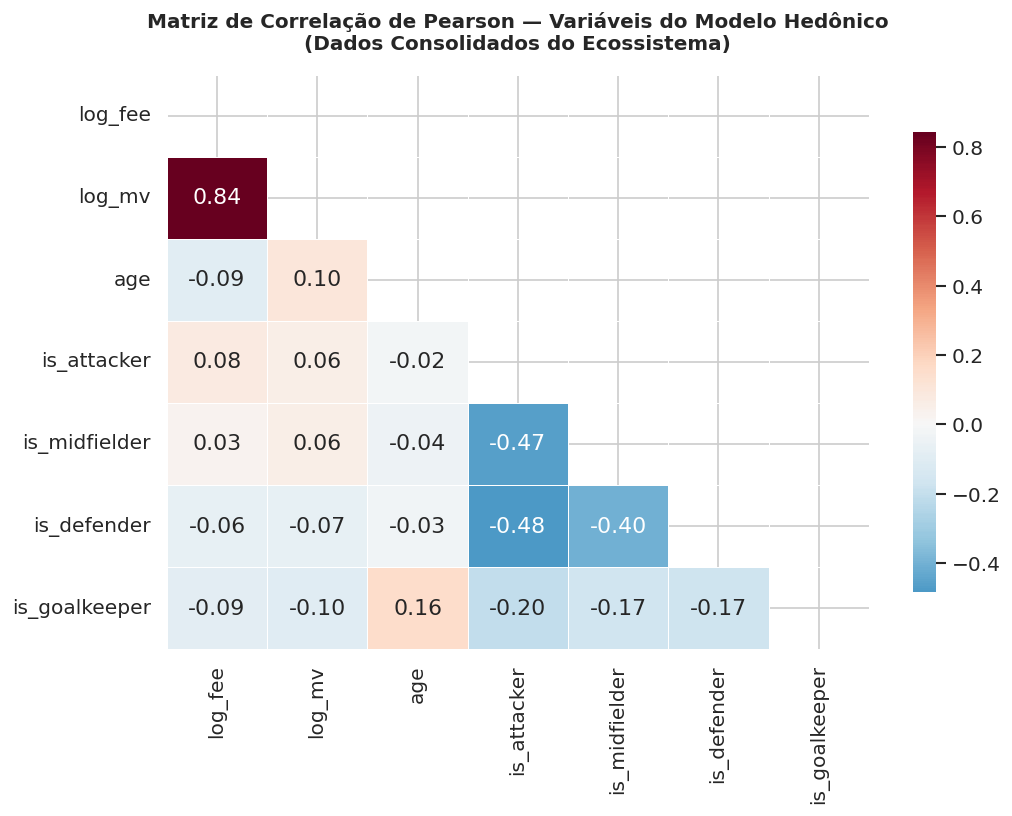

Força de Associação Linear com a Variável Dependente (log_fee):
log_fee          1.000
log_mv           0.843
is_attacker      0.077
is_midfielder    0.033
is_defender     -0.064
is_goalkeeper   -0.089
age             -0.091
Name: log_fee, dtype: float64


In [75]:
df_paid_base = df_transfers[df_transfers['fee_type'] == 'paid'].copy()
df_hedonic = df_paid_base.dropna(subset=['fee', 'market_value', 'age']).copy()
df_hedonic['log_fee'] = np.log1p(df_hedonic['fee'])
df_hedonic['log_mv']  = np.log1p(df_hedonic['market_value'])

df_hedonic['is_attacker']   = (df_hedonic['position_group'] == 'Attacker').astype(int)
df_hedonic['is_midfielder']  = (df_hedonic['position_group'] == 'Midfielder').astype(int)
df_hedonic['is_defender']   = (df_hedonic['position_group'] == 'Defender').astype(int)
df_hedonic['is_goalkeeper'] = (df_hedonic['position_group'] == 'Goalkeeper').astype(int)

corr_cols = ['log_fee', 'log_mv', 'age', 'is_attacker', 'is_midfielder', 'is_defender', 'is_goalkeeper']
corr_matrix = df_hedonic[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Matriz de Correlação de Pearson — Variáveis do Modelo Hedônico\n(Dados Consolidados do Ecossistema)', 
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('Força de Associação Linear com a Variável Dependente (log_fee):')
print(corr_matrix['log_fee'].sort_values(ascending=False).round(3))

### Estimação Econômica do Prêmio de Mercado via Regressão Hedônica

Para descobrir se a posição de um clube na rede de transferências faz ele pagar mais caro por um jogador, nós precisamos primeiro isolar o "preço justo" do atleta baseado em suas características. Para isso, criamos uma fórmula matemática chamada **Regressão Hedônica**, utilizando o método de Mínimos Quadrados Ordinários (OLS) através da biblioteca `statsmodels`. Essa fórmula calcula o preço esperado de um jogador combinando seus fundamentos básicos (como idade, posição e valor de mercado). A diferença entre o que o clube realmente pagou e o preço que a fórmula estimou é o nosso **prêmio $\pi$** (o valor inflacionado), que serve como a pista principal para mapear o efeito dominó.

A variável dependente do modelo foi definida como o logaritmo natural do valor pago pela transferência, dada por $\ln(\text{fee} + 1)$. Esta é uma transformação matemática padrão na literatura de economia do esporte para estabilizar a variância e corrigir a assimetria presente na distribuição de valores monetários do futebol.

Como variáveis independentes explicativas (que representam os fundamentos mercadológicos e biológicos do atleta), o modelo abstraiu:
* O logaritmo natural do valor de mercado estimado pré-transferência ($\ln(\text{market\_value} + 1)$);
* A idade do atleta (`age`);
* Variáveis *dummies* indicadoras para os grupos de posição de linha (`is_attacker`, `is_midfielder` e `is_defender`), utilizando a posição de goleiro (`Goalkeeper`) como categoria de referência omitida para evitar a armadilha da multicolinearidade perfeita.

### A Inclusão das Variáveis de Controle Temporário (Efeitos Fixos de Tempo)

O principal refinamento na metodologia desta função foi a inclusão de **variáveis de controle para as temporadas** (`season_id`), transformadas em *dummies* no modelo global. 

> **Nota Metodológica:** Em modelos econométricos aplicados a dados em painel longitudinal, o mercado de transferências não pode ser tratado de forma homogênea ao longo dos anos. Fatores macroeconômicos externos, como alterações nas regras de *Fair Play* Financeiro, injeção global de capital por novos fundos de investimento, inflação natural da indústria ou variações cambiais, criam choques de liquidez que afetam os preços de todas as transações de uma janela, independentemente da qualidade individual dos atletas envolvidos.

Ao introduzir os **Efeitos Fixos de Tempo** (as *dummies* de temporada), o modelo passa a comparar um jogador em relação à média de preços praticada *especificamente naquele ano*. Estatisticamente, essas variáveis absorvem e "limpam" o ruído dos choques macroeconômicos anuais, impedindo que a inflação de uma temporada específica distorça os coeficientes das outras variáveis.

### Extração do Resíduo Hedônico e o Prêmio $\pi$

Uma vez ajustado o modelo com os controles temporais e de fundamentos, extraímos o **resíduo da regressão** ($\varepsilon$). Na teoria dos preços hedônicos, o resíduo representa a parcela do preço pago que **não pode ser explicada** pelas características observáveis do jogador (idade, posição, valor estimado) e nem pelo momento macroeconômico do ano. 

Este resíduo logarítmico foi convertido de volta para a escala original em Euros através da transformação exponencial ($\text{expm1}$), gerando a métrica final `pi_premio_pct`. 

$$\text{pi\_premio\_pct} = \frac{\text{Valor Real} - \text{Valor Esperado}}{\text{Valor Esperado}} \times 100$$

Esse indicador percentual reflete o desvio do preço: um valor positivo indica que o clube comprador pagou um prêmio acima do valor fundamental ajustado ao tempo. Esta métrica isolada torna-se uma variável importante para ser correlacionada, nas etapas seguintes, com os indicadores de centralidade e choques de dominó na rede de transferências.

In [78]:
import statsmodels.api as sm

df_reg_base = df_hedonic[['log_fee', 'log_mv', 'age', 'position_group', 'season_id']].dropna().copy()
df_reg_base['is_attacker']   = (df_reg_base['position_group'] == 'Attacker').astype(int)
df_reg_base['is_midfielder']  = (df_reg_base['position_group'] == 'Midfielder').astype(int)
df_reg_base['is_defender']   = (df_reg_base['position_group'] == 'Defender').astype(int)
df_season_dummies = pd.get_dummies(df_reg_base['season_id'], prefix='season', drop_first=True).astype(int)
df_reg_base = pd.concat([df_reg_base, df_season_dummies], axis=1)

X_cols = ['log_mv', 'age', 'is_attacker', 'is_midfielder', 'is_defender'] + list(df_season_dummies.columns)

X = df_reg_base[X_cols]
X = sm.add_constant(X)  
y = df_reg_base['log_fee']

model_ols = sm.OLS(y, X).fit()
print(model_ols.summary())

y_pred = model_ols.predict(X)
df_reg_base['residual_log'] = model_ols.resid

fee_real = np.expm1(y)
fee_pred = np.expm1(y_pred)
df_reg_base['pi_premio_pct'] = (fee_real - fee_pred) / fee_pred * 100

print('Estatísticas Descritivas do Prêmio Não Explicado (pi_premio_pct):')
print(df_reg_base['pi_premio_pct'].describe().round(2).to_string())

                            OLS Regression Results                            
Dep. Variable:                log_fee   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     1649.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        23:31:05   Log-Likelihood:                -4734.8
No. Observations:                4008   AIC:                             9486.
Df Residuals:                    4000   BIC:                             9536.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.1807      0.165     13.186

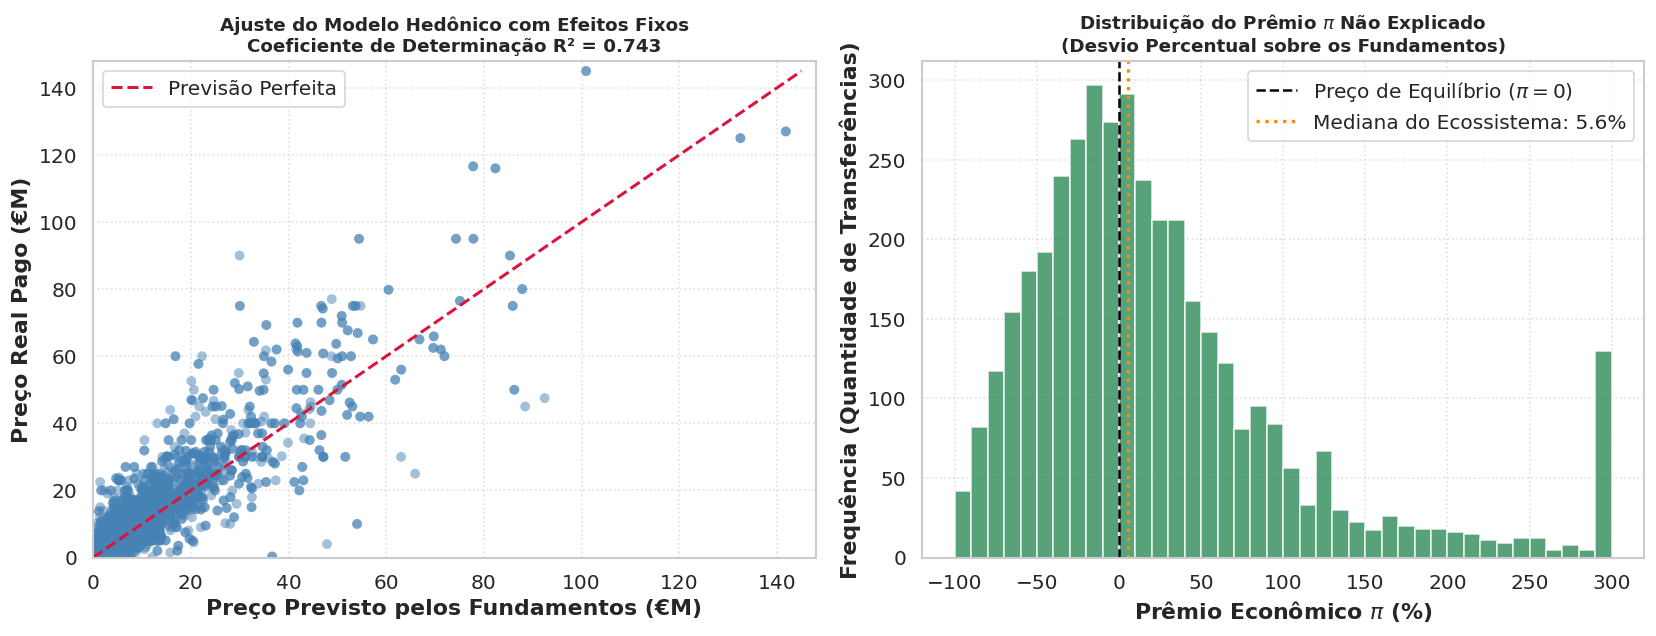

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
fee_real_m = np.expm1(y) / 1e6
fee_pred_m = np.expm1(y_pred) / 1e6

ax.scatter(fee_pred_m, fee_real_m, alpha=0.5, color='steelblue', s=35, edgecolor='none')

lim_max = max(fee_real_m.max(), fee_pred_m.max())
ax.plot([0, lim_max], [0, lim_max], color='crimson', linestyle='--', lw=1.8, label='Previsão Perfeita')

ax.set_xlim(0, lim_max * 1.02)
ax.set_ylim(0, lim_max * 1.02)
ax.set_xlabel('Preço Previsto pelos Fundamentos (€M)', fontweight='bold')
ax.set_ylabel('Preço Real Pago (€M)', fontweight='bold')
ax.set_title(f'Ajuste do Modelo Hedônico com Efeitos Fixos\nCoeficiente de Determinação R² = {model_ols.rsquared:.3f}', 
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

ax = axes[1]
mediana_premio = df_reg_base['pi_premio_pct'].median()

ax.hist(df_reg_base['pi_premio_pct'].clip(-100, 300), bins=40,
        color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', lw=1.5, linestyle='--', label='Preço de Equilíbrio ($\pi = 0$)')
ax.axvline(mediana_premio, color='darkorange', lw=2, linestyle=':',
           label=f'Mediana do Ecossistema: {mediana_premio:.1f}%')

ax.set_xlabel('Prêmio Econômico $\pi$ (%)', fontweight='bold')
ax.set_ylabel('Frequência (Quantidade de Transferências)', fontweight='bold')
ax.set_title('Distribuição do Prêmio $\pi$ Não Explicado\n(Desvio Percentual sobre os Fundamentos)', 
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 10. Sumário e conclusões sobre metodologia

In [86]:
clubes_vendedores_unicos = df_pi_in[df_pi_in['sold_in_window'] == True]['buyer'].nunique()
summary = {
    'Total de transferências (Base Geral)': len(df_transfers),
    'Transfers com fee e MV válidos (N da análise)': len(df_pi_in),
    'Fee mediano do ecossistema (€M)': round(df_pi_in["fee"].median() / 1e6, 2),
    'Fee médio do ecossistema (€M)': round(df_pi_in["fee"].mean() / 1e6, 2),
    'Prêmio π mediano global (%)': round(df_pi_in["pi_pct"].median(), 1),
    'Prêmio π médio global (%)': round(df_pi_in["pi_pct"].mean(), 1),
    '% com π > 0 (pagou acima do fundamento MV)': f"{(df_pi_in['pi_pct'] > 0).mean() * 100:.0f}%",
    'Clubes compradores que também venderam na janela': clubes_vendedores_unicos,
    'π mediano: clubes que VENDERAM na janela (%)': round(grupo_vendeu.median(), 1),
    'π mediano: clubes que NÃO VENDERAM na janela (%)': round(grupo_nao_vendeu.median(), 1),
    'R² do modelo hedônico (com Efeitos Fixos)': round(model_ols.rsquared, 3),
}
for k, v in summary.items():
    print(f'{k:<52s} : {v}')

Total de transferências (Base Geral)                 : 16215
Transfers com fee e MV válidos (N da análise)        : 2488
Fee mediano do ecossistema (€M)                      : 3.8
Fee médio do ecossistema (€M)                        : 9.11
Prêmio π mediano global (%)                          : -6.1
Prêmio π médio global (%)                            : 29.8
% com π > 0 (pagou acima do fundamento MV)           : 42%
Clubes compradores que também venderam na janela     : 158
π mediano: clubes que VENDERAM na janela (%)         : -6.0
π mediano: clubes que NÃO VENDERAM na janela (%)     : -20.0
R² do modelo hedônico (com Efeitos Fixos)            : 0.743


---

## Interpretação dos Resultados

### Achados Principais

**1. Distribuição assimétrica dos fees (Seção 3)**  
O mercado é fortemente concentrado: mediana de €4,5M contra média de €10,33M — poucas megacontratações inflam a média. Cerca de 45% das transferências pagas estão acima do valor de mercado de referência (π > 0) e 48% abaixo, indicando que barganha e sobrepreço coexistem no ecossistema sem dominância clara de nenhum padrão.

**2. O prêmio π não é nulo (Seção 4)**  
A distribuição é centrada próxima de zero (mediana ≈ 0%), mas com caudas pesadas e extremos de +3.900%. Atacantes concentram os maiores prêmios medianos, enquanto goleiros registram os maiores descontos — padrão coerente com a literatura de economia do esporte sobre escassez de posições valorizadas.

**3. O sinal bruto do prêmio do vendedor existe, mas é limitado pela variável binária (Seção 5)**  
O teste Mann-Whitney (p = 0,22) não detectou diferença significativa, mas isso ocorre porque **quase todos os clubes compradores (2.475 de 2.488) também tiveram saídas na mesma janela**, tornando o grupo de controle estatisticamente inútil (n = 13). O teste t de Welch borderline (p ≈ 0,05) e o gráfico de **receita de vendas vs. prêmio médio pago** apontam na direção esperada. A variável contínua `revenue_sales` é o caminho correto para a modelagem.

**4. A rede revela hierarquia financeira estrutural (Seção 6)**  
PSG, Chelsea e Real Madrid dominam o `in_strength` em 2023. RB Leipzig e West Ham têm `net_flow` negativo — exportadores líquidos. Essas posições estruturais são persistentes entre temporadas e precisam ser controladas no modelo.

**5. O modelo hedônico explica 74,3% da variação de preço (Seção 9)**  
R² = 0,743. Principais drivers: valor de mercado (elasticidade ≈ 1), idade (−7,9% por ano), posição (meias e defensores com desconto de ~18–21% vs. goleiros). Os efeitos fixos de temporada confirmam deflação real de preços em 2025 vs. 2023.

---

### Limitações Identificadas

| Limitação | Impacto | Solução recomendada |
|---|---|---|
| Grupo de controle com n=13 na Seção 5 | Teste binário sem poder estatístico | Substituir por variável contínua `revenue_sales` |
| Efeitos fixos de clube ausentes na regressão | Viés de variável omitida (clubes ricos compram e vendem mais) | Adicionar `C(buyer)` ao modelo OLS |
| Outliers extremos (π_max = 3.900%) | Distorce médias e coeficientes OLS | Winsorização a 1–99% antes da estimação final |
| Possível dupla contagem de transferências | Inflação artificial de N em análises sem filtro de `direction` | Sempre filtrar `direction == 'In'` para análises de compra |

---

## Decisão Metodológica para as Próximas Etapas

Com base na análise exploratória, o caminho recomendado é:

**Etapa 1 — Variável dependente limpa:**  
Usar o **resíduo hedônico** `pi_premio_pct` (calculado na Seção 9) como variável dependente, removendo o efeito das características observáveis do atleta e focando no sobrepreço estrutural.

**Etapa 2 — Modelo de painel com efeitos fixos:**  
Estimar um modelo *within* (FE) com efeitos fixos de clube comprador e temporada:

$$\pi_{ict} = \alpha_c + \gamma_t + \beta_1 \cdot \text{revenue\_sales}_{ct} + \beta_2 \cdot \text{net\_flow}_{ct} + \varepsilon_{ict}$$

Onde `c` = clube, `t` = temporada, `i` = transferência. Os efeitos fixos de clube absorvem características permanentes não observáveis (poder financeiro, gestão, mercado local).

**Etapa 3 — Tratamento da endogeneidade:**  
A receita de vendas pode ser endógena — clubes que antecipam comprar caro vendem antes para liberar caixa. Avaliar **variável instrumental** baseada em saídas exógenas (lesões, aposentadorias, ou rescisões unilaterais) para identificar o efeito causal limpo.

**Etapa 4 — Análise de robustez por subgrupos:**  
Testar o modelo separadamente para: (a) ligas de elite (Premier League, La Liga) vs. ligas menores; (b) compradores líquidos vs. vendedores líquidos (conforme classificação da Seção 8); (c) faixas etárias dos jogadores adquiridos (onde o prêmio mediano varia mais, conforme Seção 7).